In [213]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


## 2
![ex2_2.png](ex2_2.png)

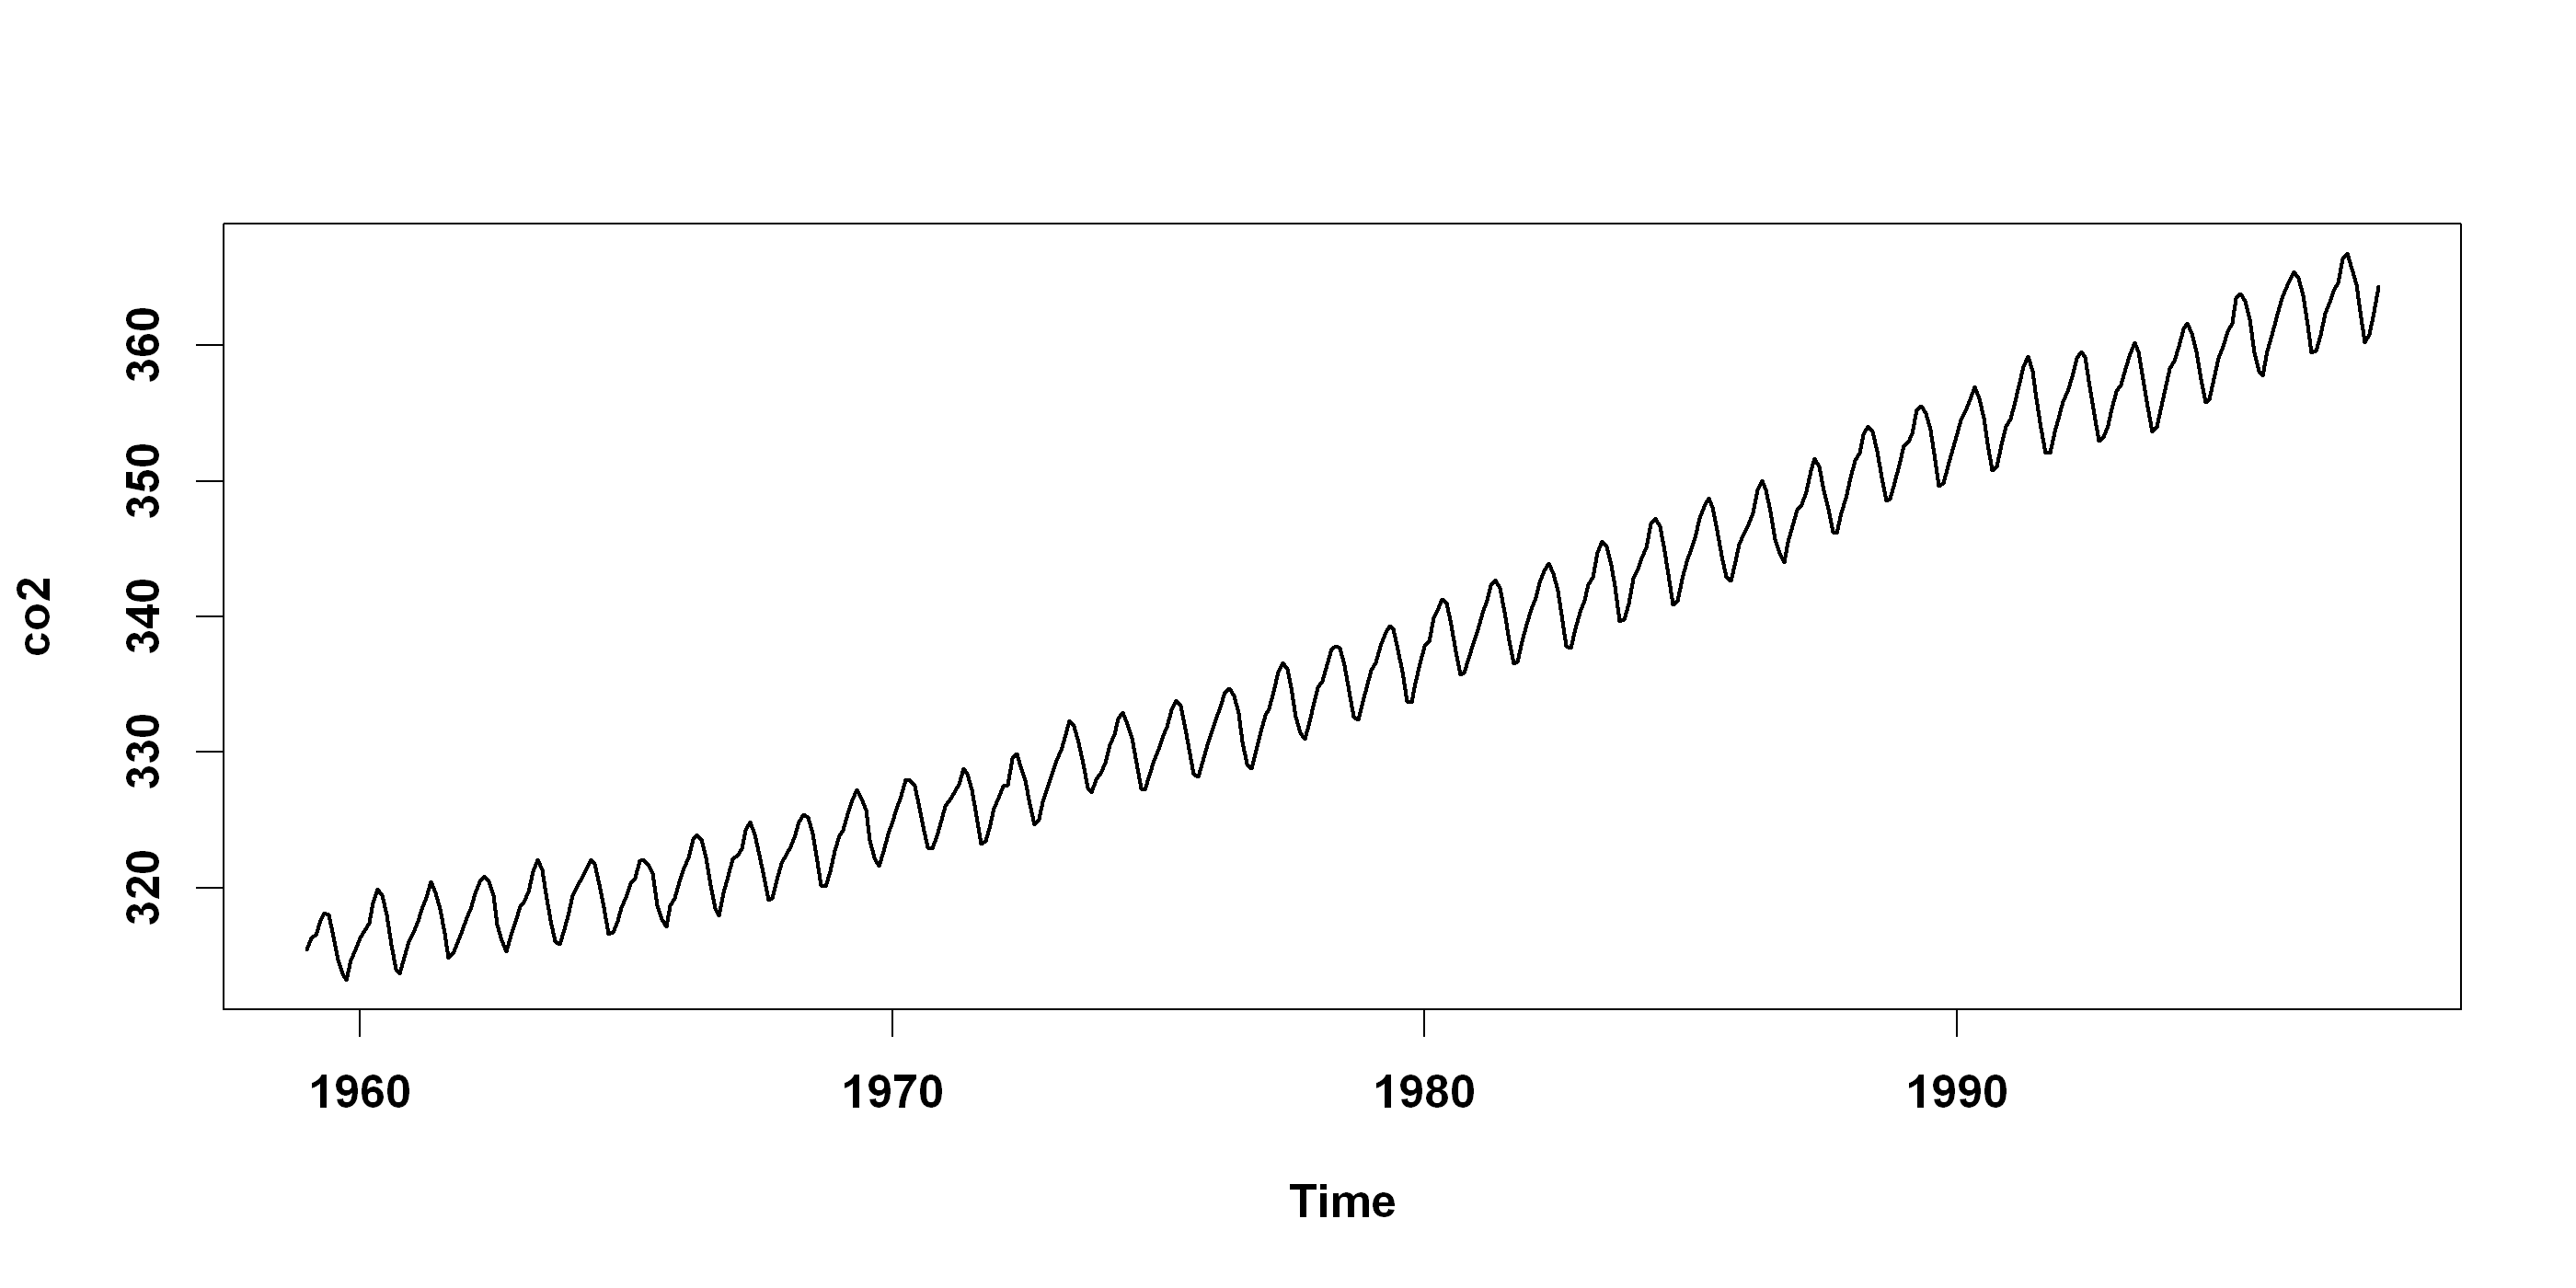

In [214]:
data(co2)
par(cex = 1.5,font.main=2,font.axis=2,font.lab=2)
plot(co2,lwd = 2)


### a

![ex2_2_a.png](ex2_2_a.png)

Non-stationary, there is a strong trend, and there is a strong seasonality (roughly once every year), which are not only the causes but the components as well in addition to the random component (i.e. the stationary remainder).

### b
![ex2_2_b.png](ex2_2_b.png)

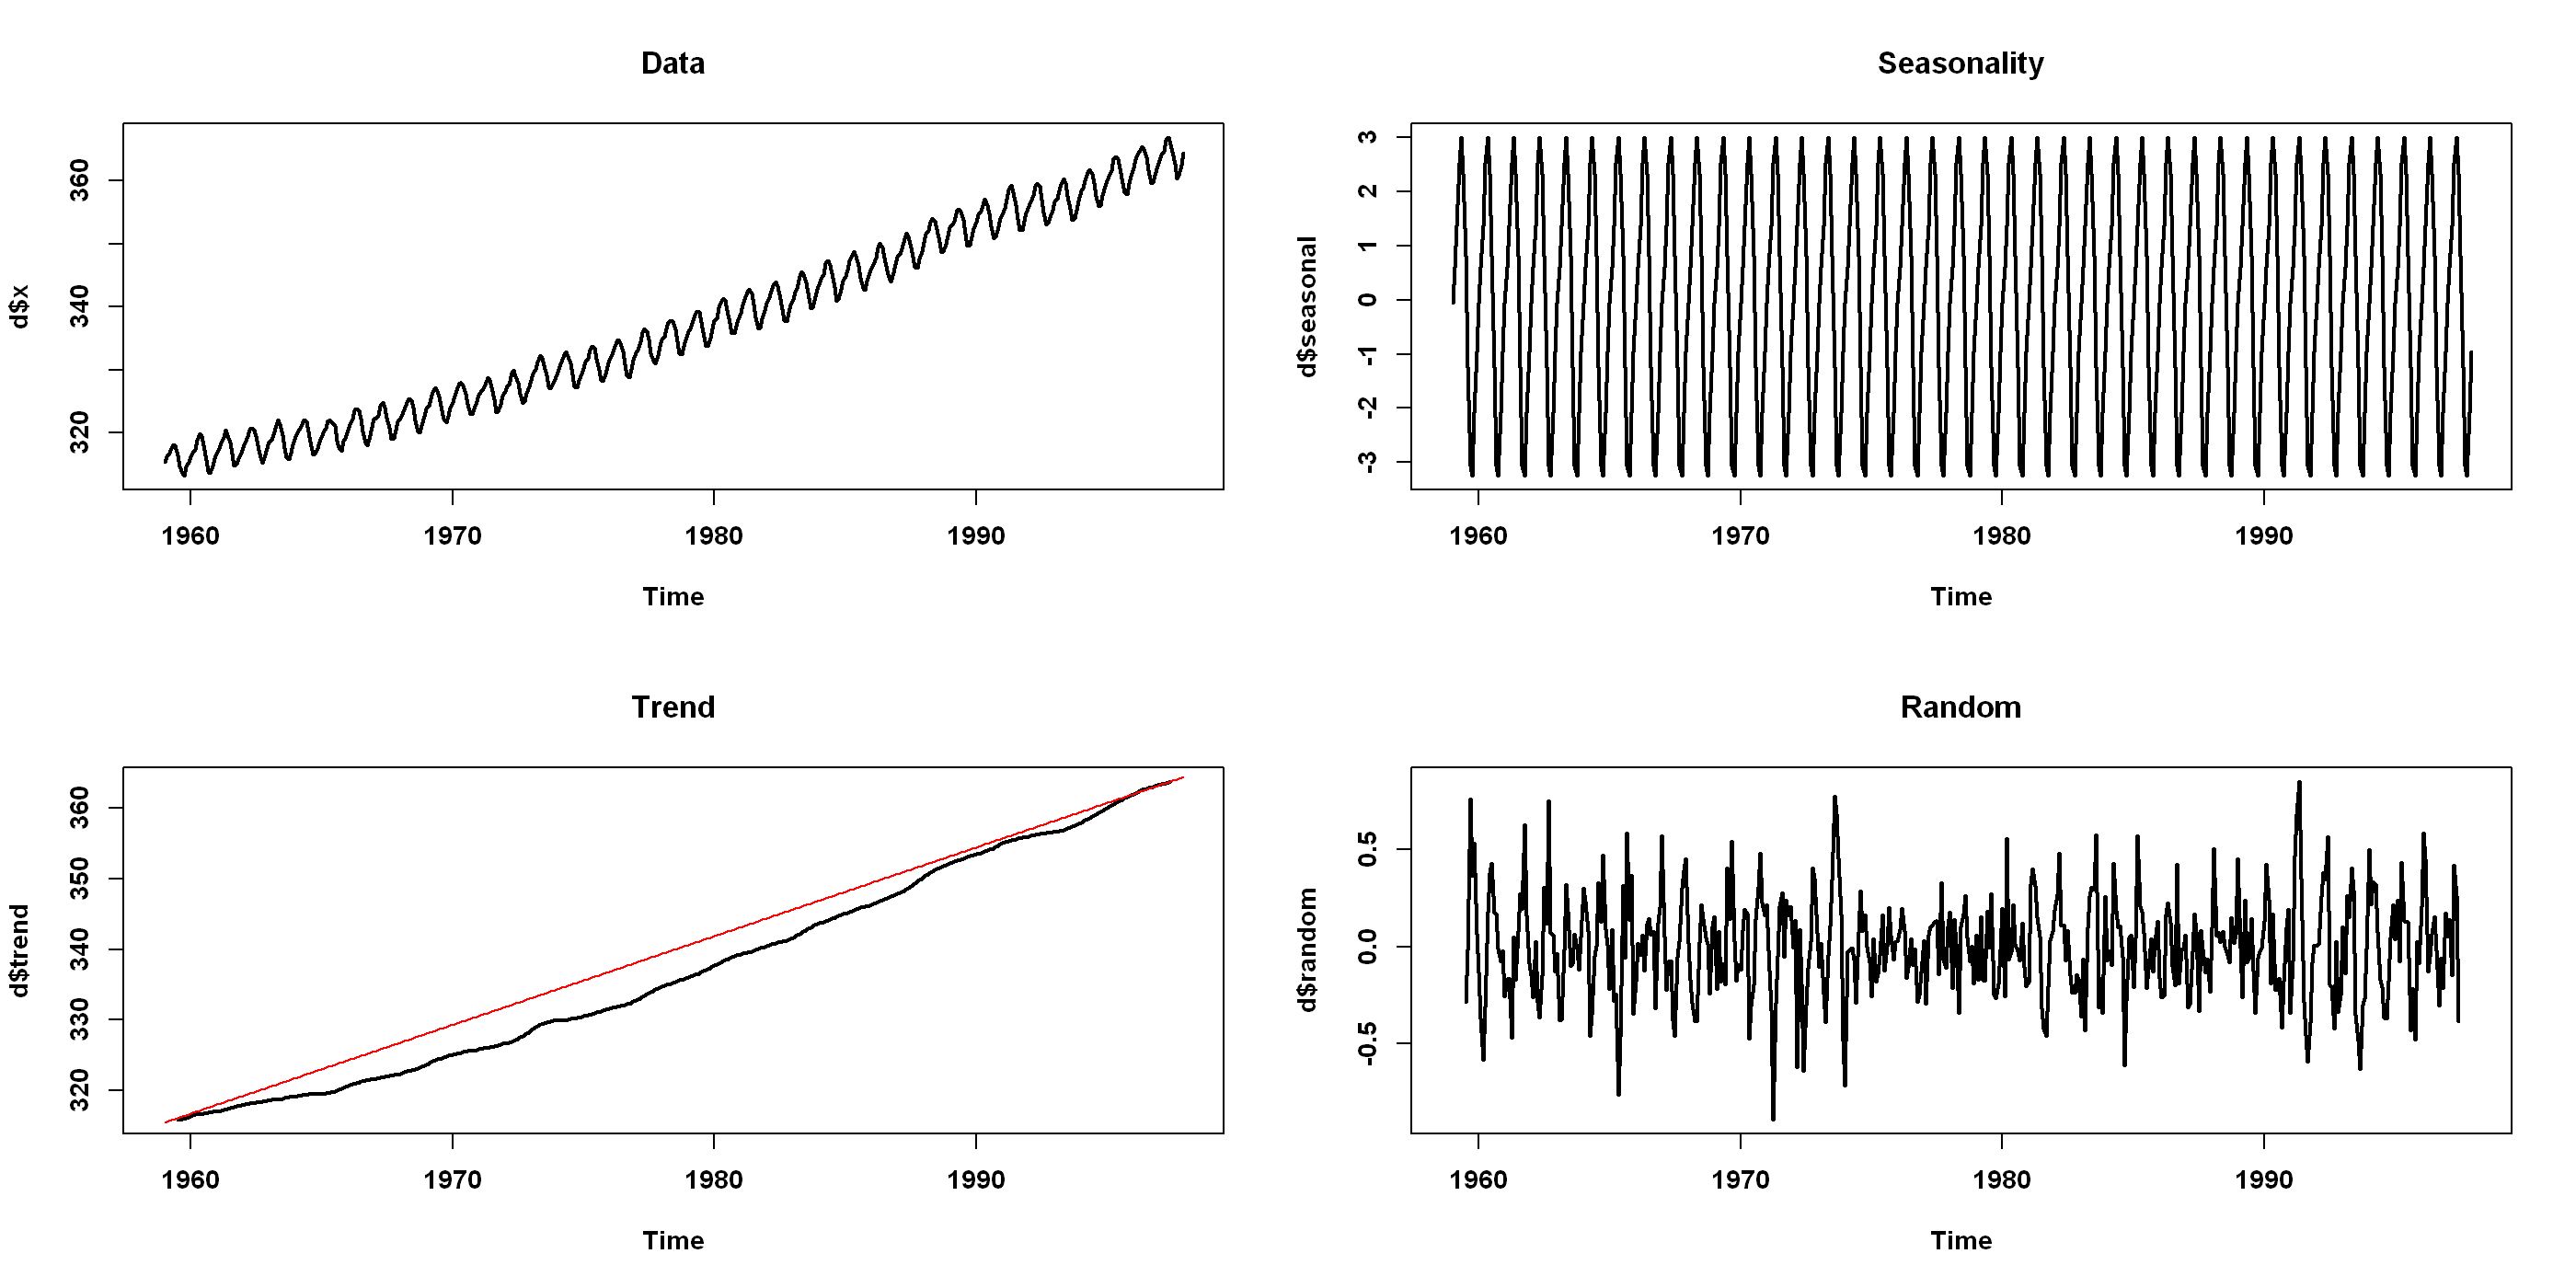

In [215]:
d = decompose(co2,type = "additive");
n = length(co2)
x = seq(1, n, length.out = n)
par(cex = 1.5,font.main=2,font.axis=2,font.lab=2,mfrow = c(2,2))
plot(d$x,lwd = 2,main = "Data")
plot(d$seasonal,lwd = 2,main = "Seasonality")
plot(d$trend,lwd = 2,main = "Trend")
lines(as.numeric(time(co2)),(co2[n]-co2[1])/n * x + co2[1],col="Red")
plot(d$random,lwd=2,main="Random")


* Thought the trend is looks close to being linear (as shown in the figure), there are slight devitions, one might argue that the trend is quasi-linear, where the non-linear part is very small in proportion to the linear one, the non-linear part is appears to be almost convex (giving the small curvature).

* The period of the sesonality appears to be roughly 12 months (for the timelength between peaks is rougly 12 units of time), and since the series has a frequency of 12 the frequency of the seasonality is 1.


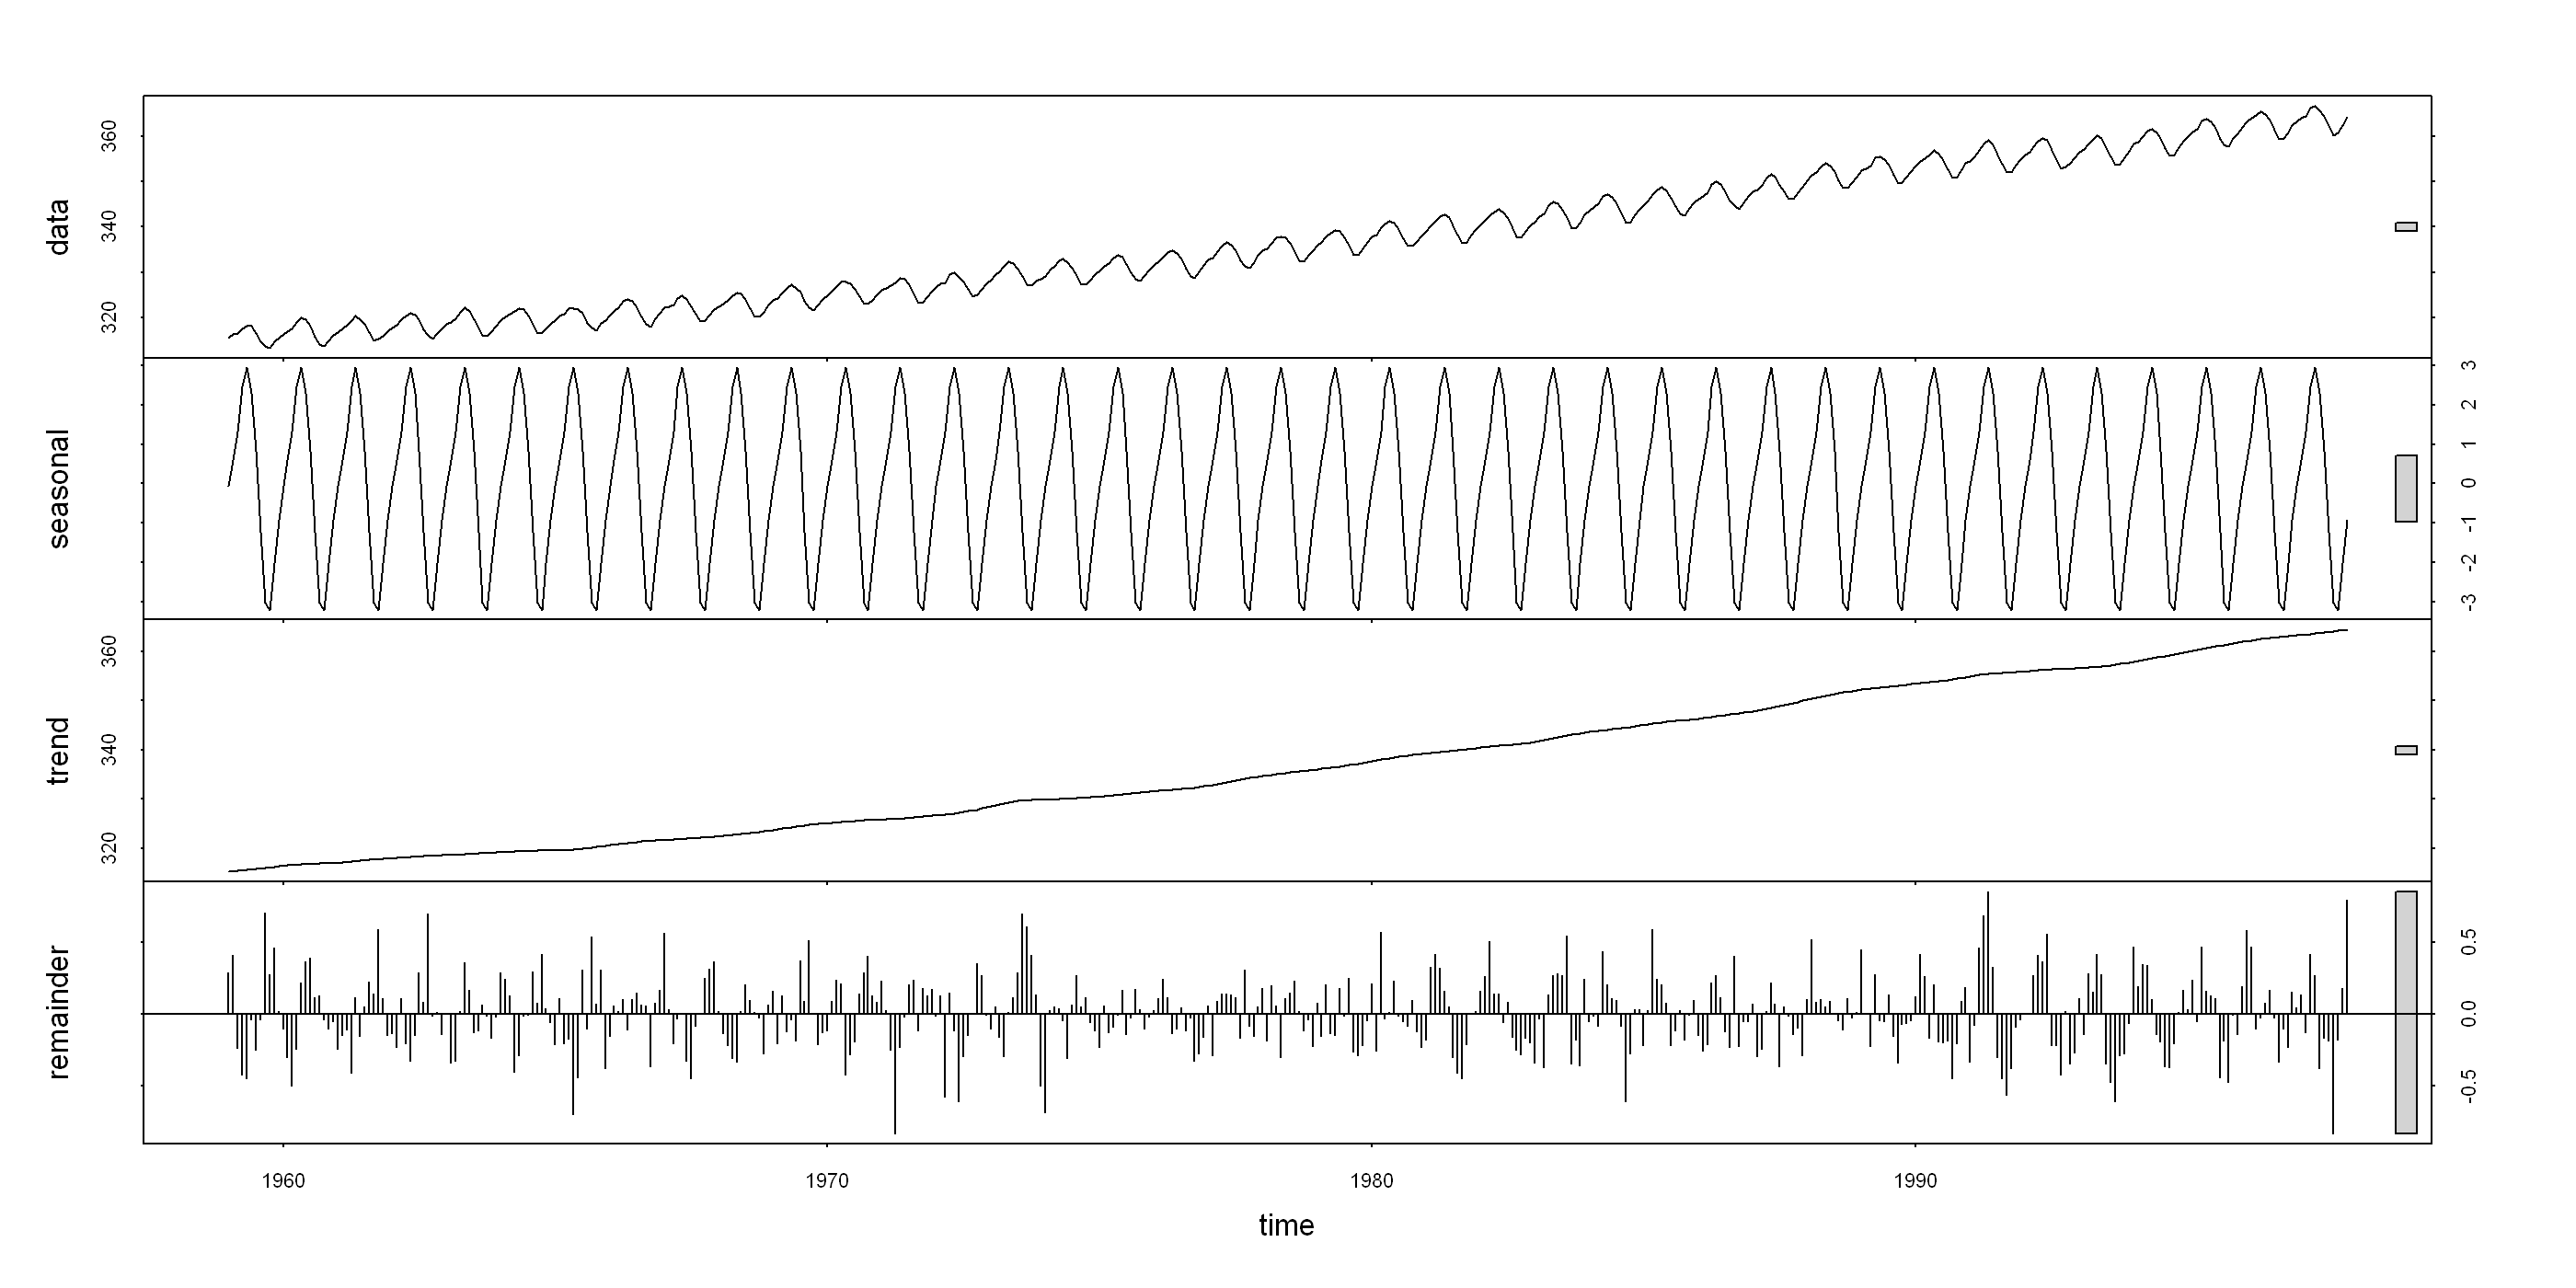

In [216]:
plot(stl(co2,s.window="periodic"))

As observed the seasonality is strong, and the trend is very strong in contrast ot the remainder.

### c
![ex2_2_c.png](ex2_2_c.png)

First of all let us define GAMs (Generalized Additive Models):

$$X_t = f(t)+\alpha_{i(t)}+R_t$$

where seasonality fit $f\in H^2(\bar{J})$, with $ \bar{J} \subseteq [0,T]$, and trend smoother $\alpha \in \mathbb{R}^K$, with $i(t)=k \; \text{when}\, t \in I_k $ with the partiton $\{I_1,\dots,I_K\}$ of $\bar{J}$, and the remainder $R_t\in\mathbb{R}$

and the underlying estimation is given via:


$$\min_{f\in H^2(\bar{J}),\alpha \in \mathbb{R}^k} \sum^k_{t=0} (X_t-(f(t)-\alpha_{i(t)}))^2+\int_{\bar{J}} (f'')^2 ds$$


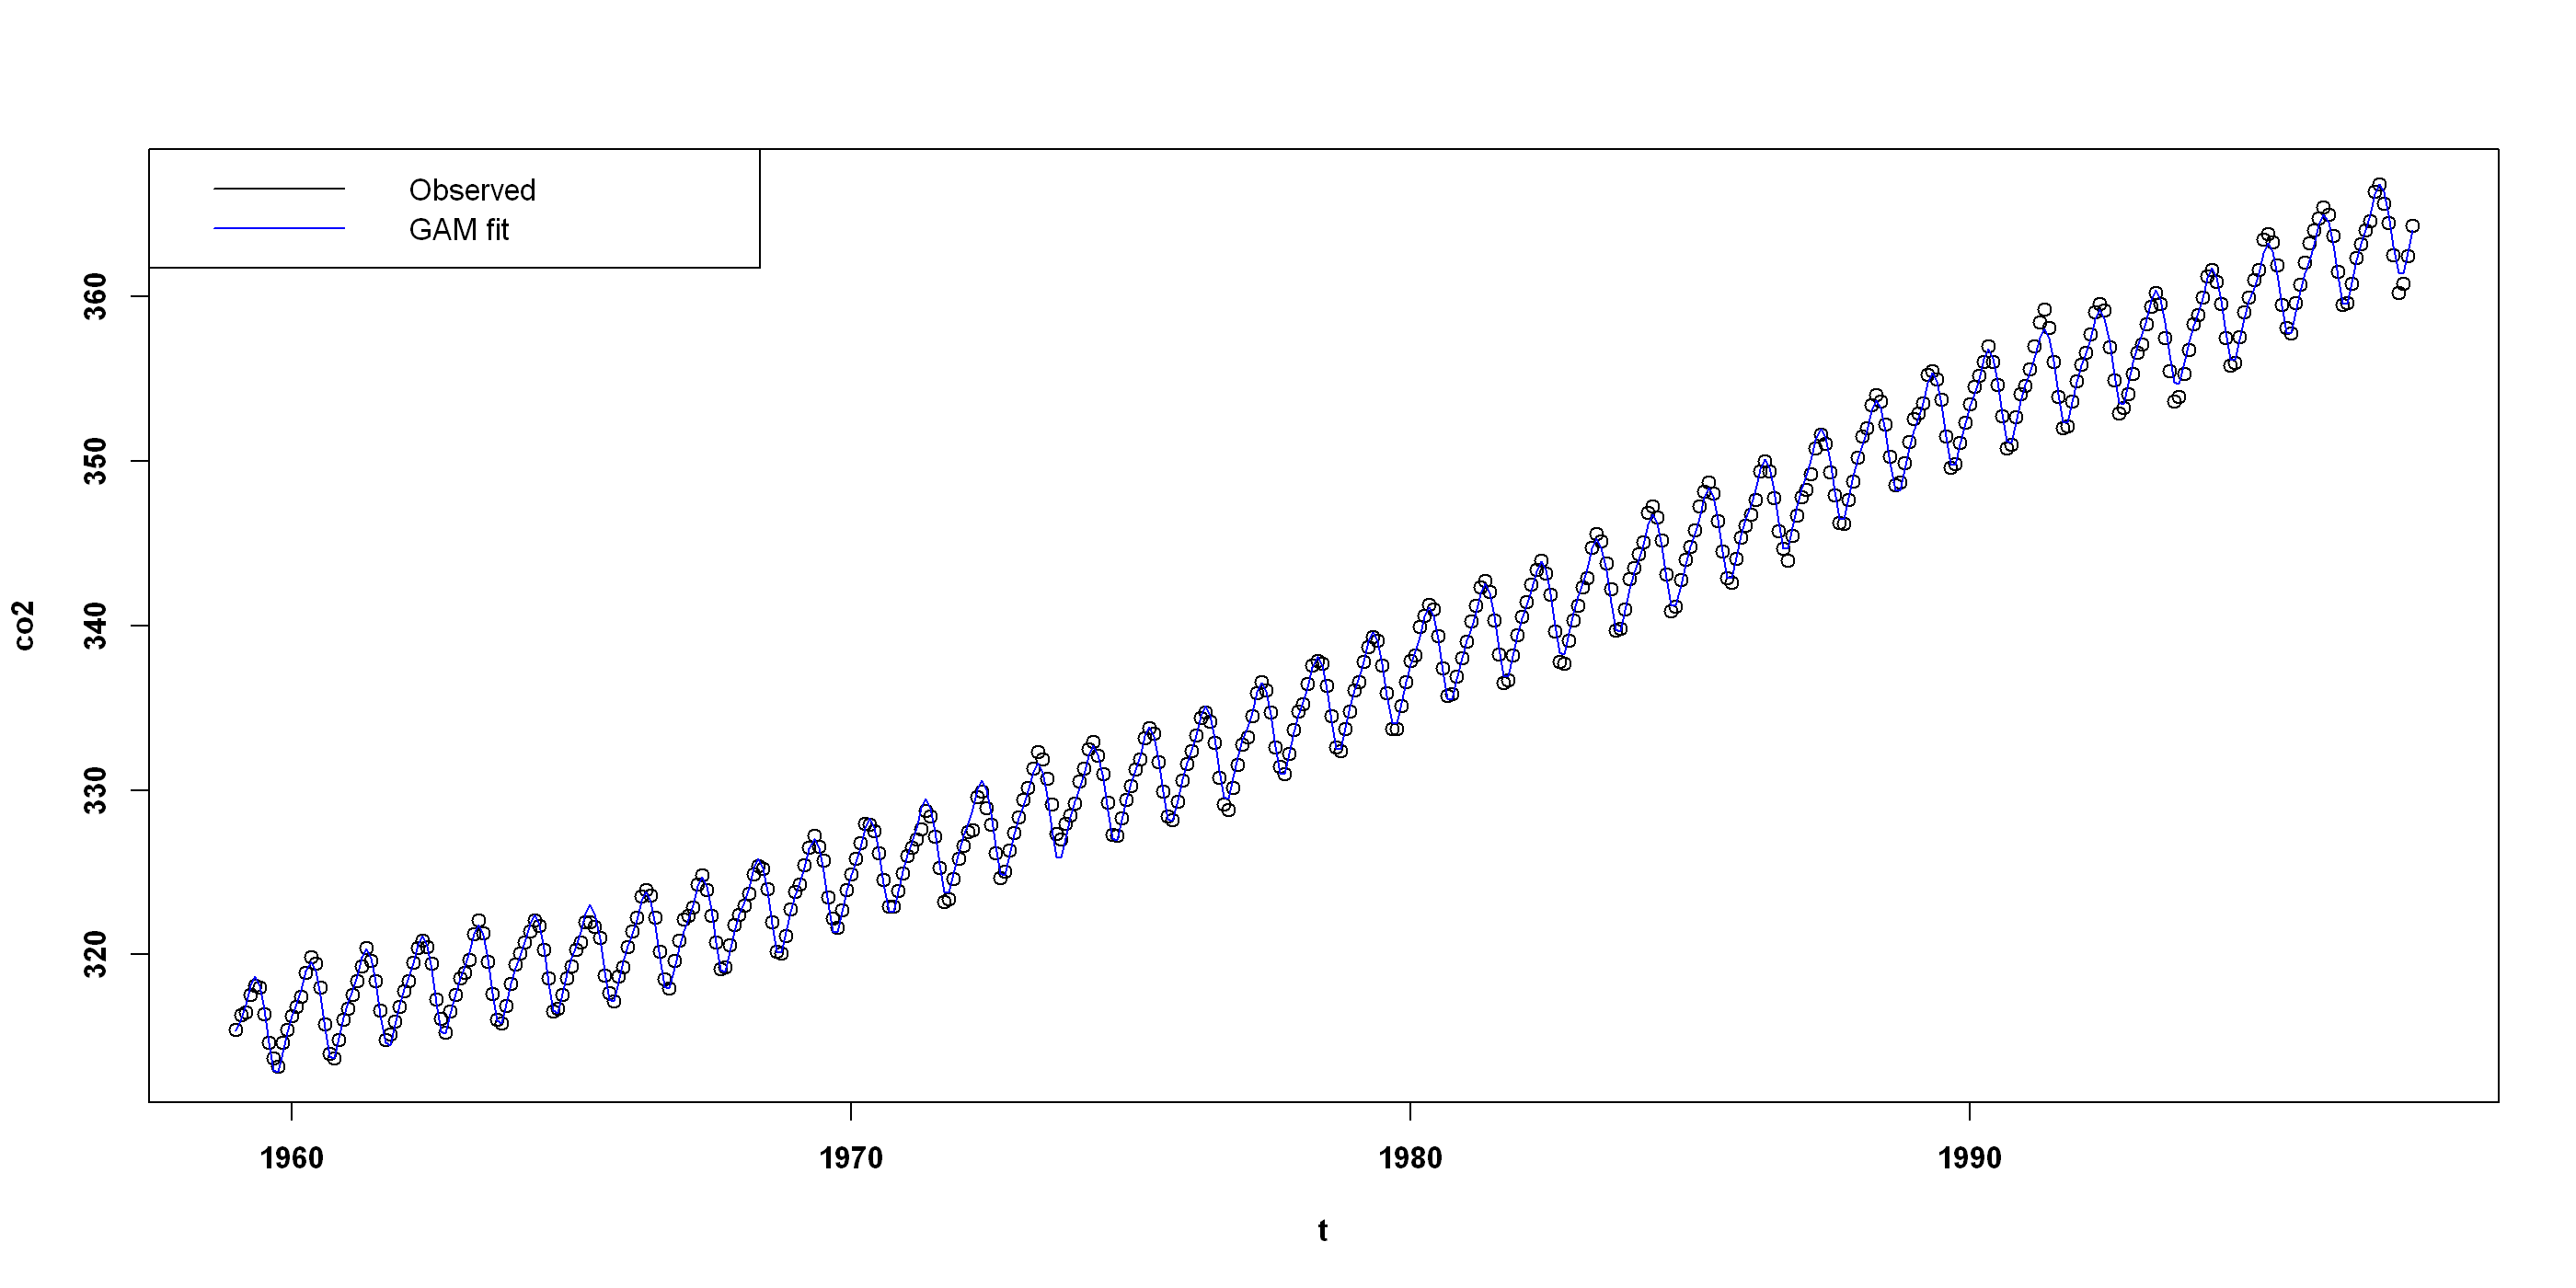

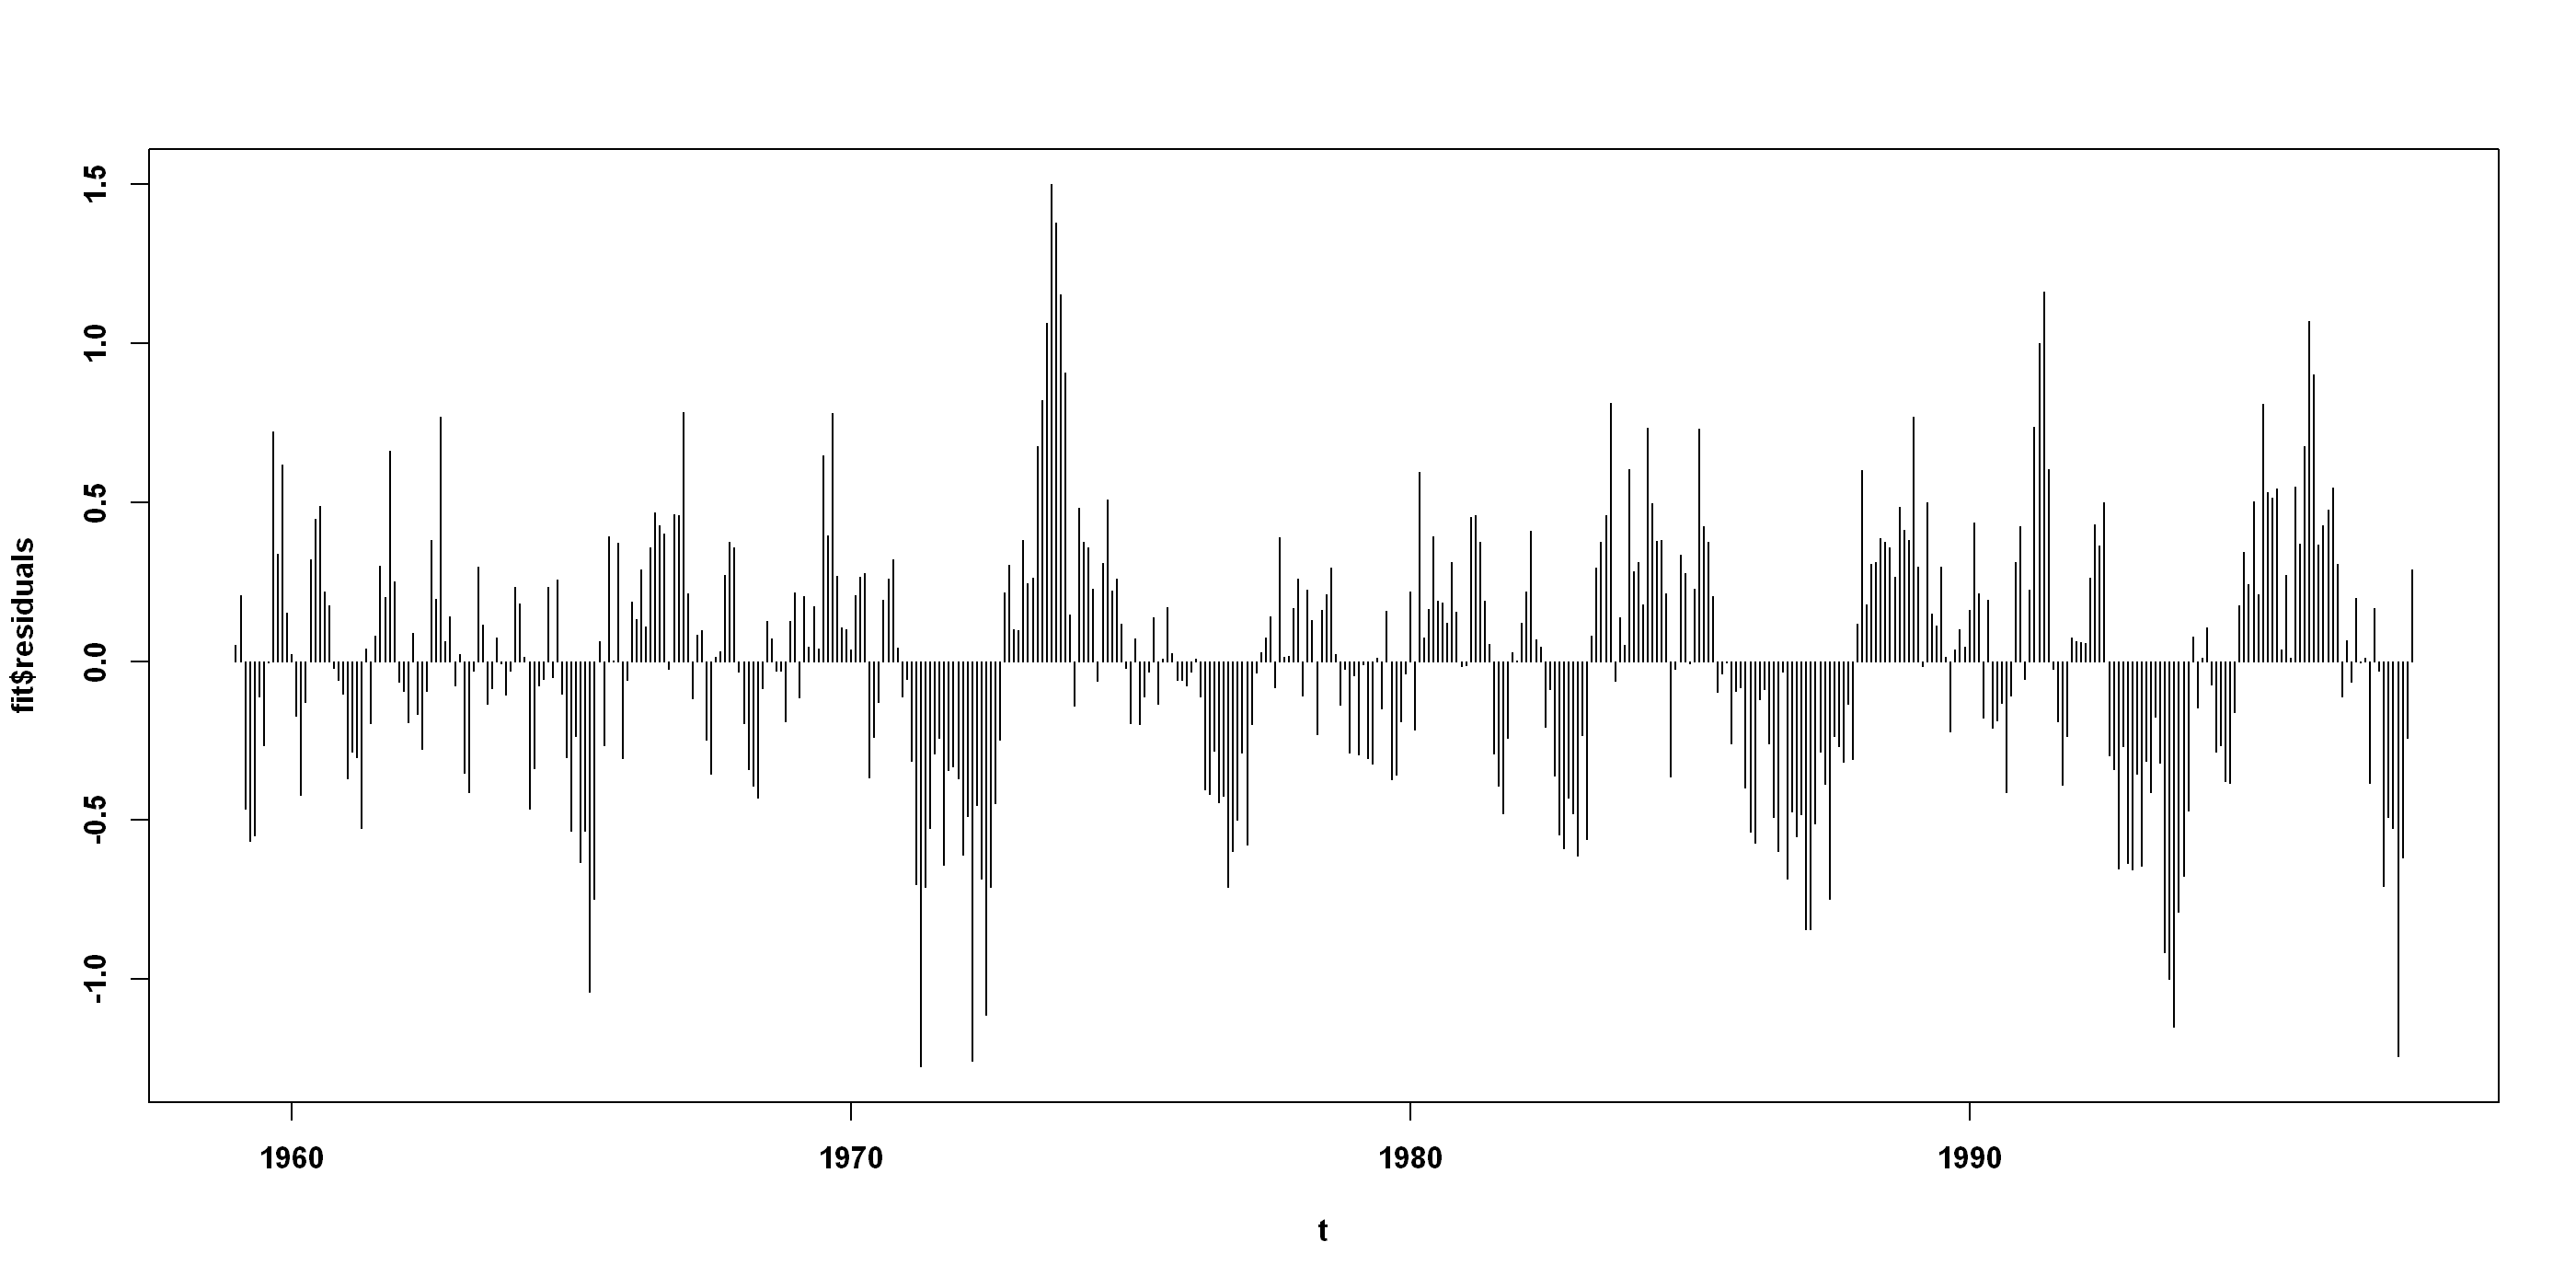

In [243]:
library(mgcv)
period = 12

n <- length(co2)
J_closed <- 1:n
I_closed <- cycle(co2)
fit <- gam(co2~s(J_closed)+s(I_closed,k=period))
par(cex = 1.5,font.main=2,font.axis=2,font.lab=2,mfrow = c(1,1))
plot(t,co2,type="p")
lines(as.numeric(t),fit$fitted.values,col="Blue")
legend("topleft", legend=c("Observed","GAM fit"), col=c("black","blue"), lty=1)

plot(t,fit$residuals,type="h")


In [218]:
summary(fit)


Family: gaussian 
Link function: identity 

Formula:
co2 ~ s(J_closed) + s(I_closed, k = period)

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 337.05353    0.01893   17801   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
              edf Ref.df     F p-value    
s(J_closed) 8.964   9.00 68176  <2e-16 ***
s(I_closed) 9.432  10.52  1108  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.999   Deviance explained = 99.9%
GCV = 0.17505  Scale est. = 0.16779   n = 468

#### c -- EXTRA

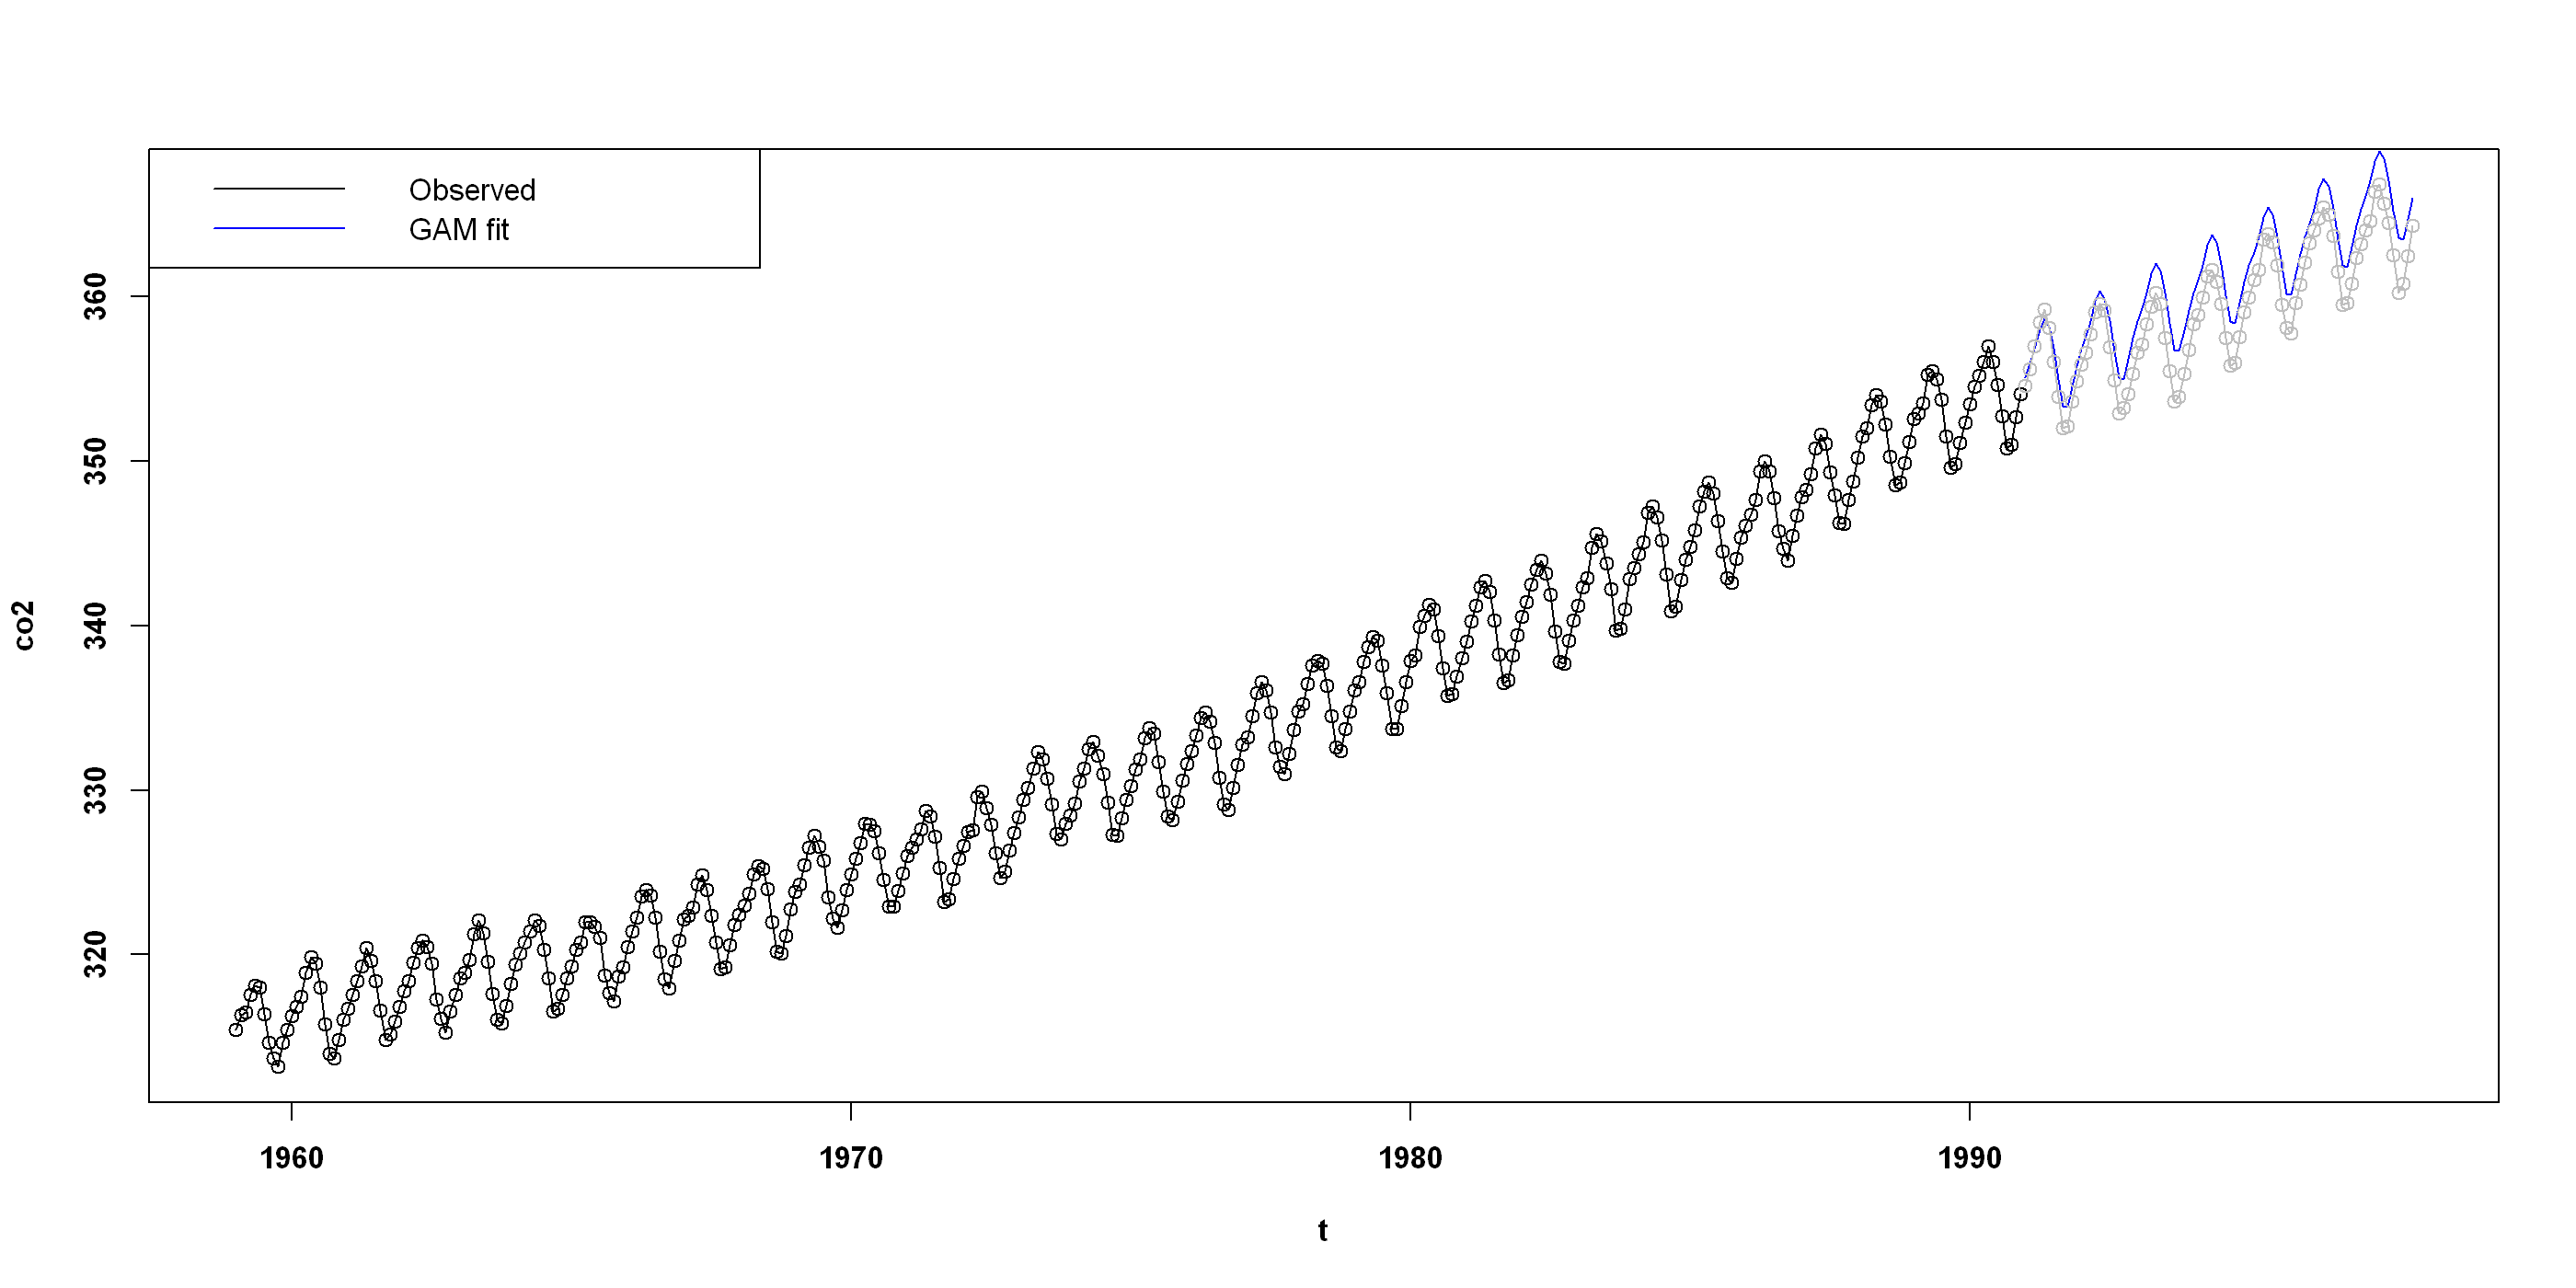

In [219]:

horizon <- 12*7 # 7 yrs
n_train <- n - horizon
end_train <- time(co2)[n_train]
start_test <- time(co2)[n_train + 1]

train <- window(co2, end = end_train)
test <- window(co2, start = start_test)

J <-1:n_train
I <-cycle(train)
fit_ <- gam(train ~ s(J) + s(I, k = period))
t=time(co2)
t_train= time(train)
t_horiz = time(test)

J_test <- (n_train + 1):n
I_test <- cycle(test)

forecast <- predict(fit_, newdata = data.frame(J = J_test, I = I_test))


par(cex = 1.5,font.main=2,font.axis=2,font.lab=2,mfrow = c(1,1))
plot(t,co2)
lines(as.numeric(t_horiz), forecast, col = "blue")
lines(as.numeric(t_train),train)
lines(as.numeric(t_horiz),test,type = 'o',col="Grey")
legend("topleft", legend=c("Observed","GAM fit"), col=c("black","blue"), lty=1)


In [220]:
summary(fit_)


Family: gaussian 
Link function: identity 

Formula:
train ~ s(J) + s(I, k = period)

Parametric coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 332.18823    0.01962   16929   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
       edf Ref.df     F p-value    
s(J) 8.649  8.964 38897  <2e-16 ***
s(I) 9.337 10.462   991  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.999   Deviance explained = 99.9%
GCV = 0.15554  Scale est. = 0.14785   n = 384

# d

![ex2_2_d.png](ex2_2_d.png)

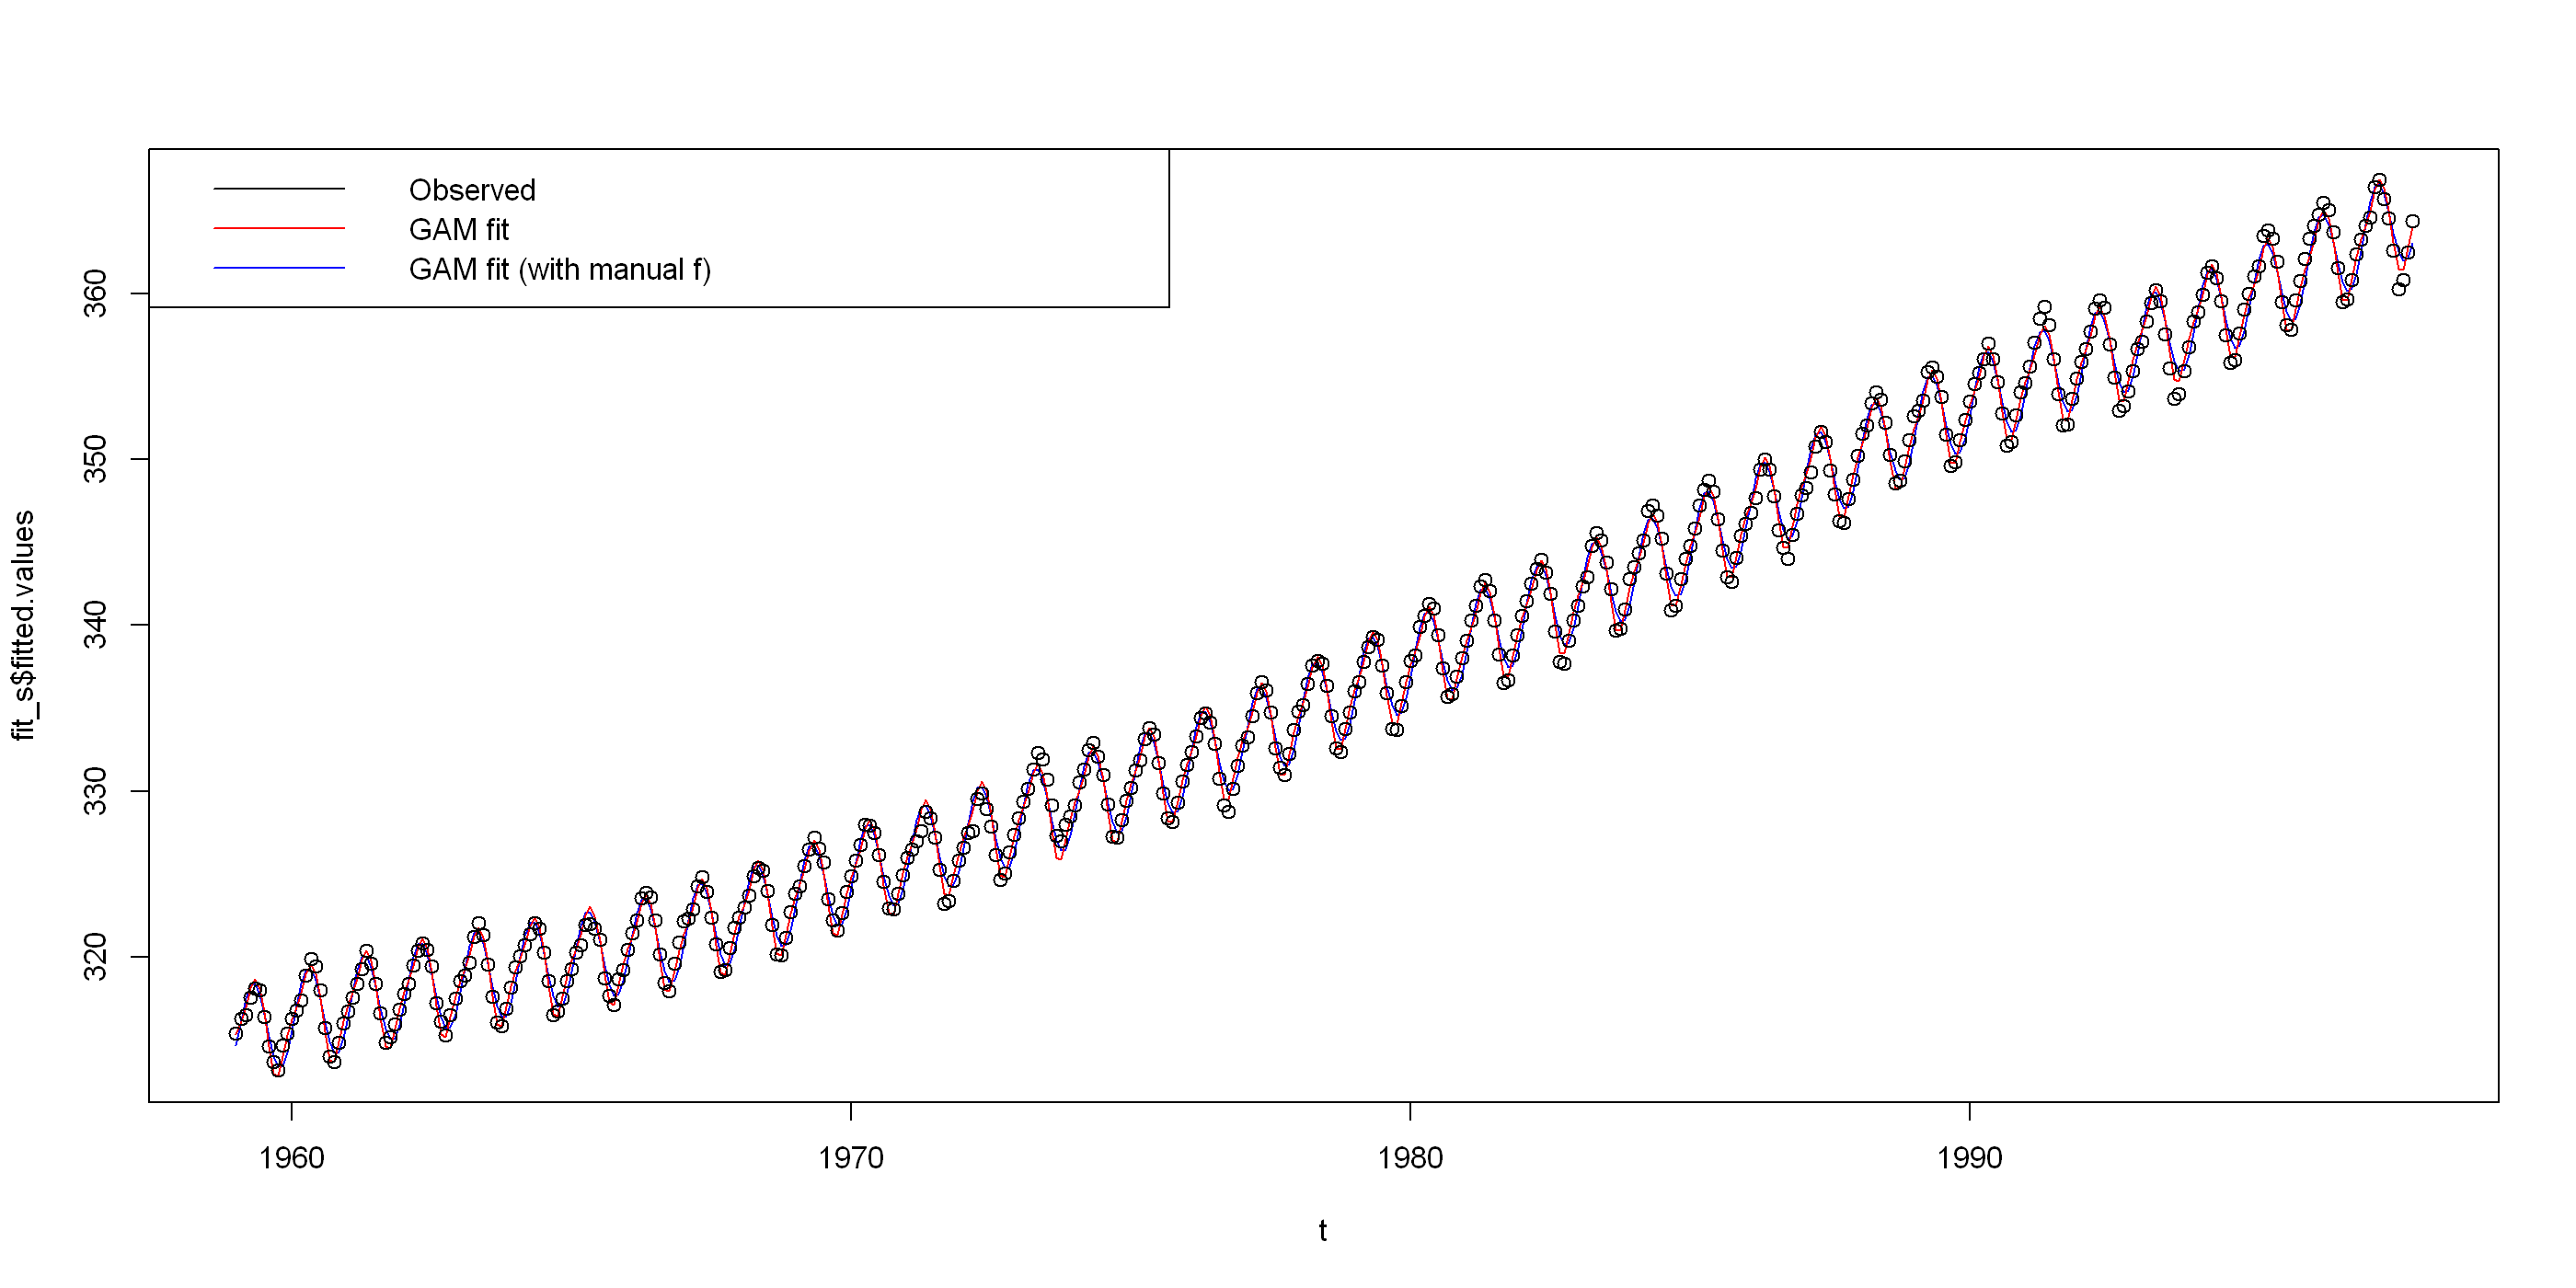

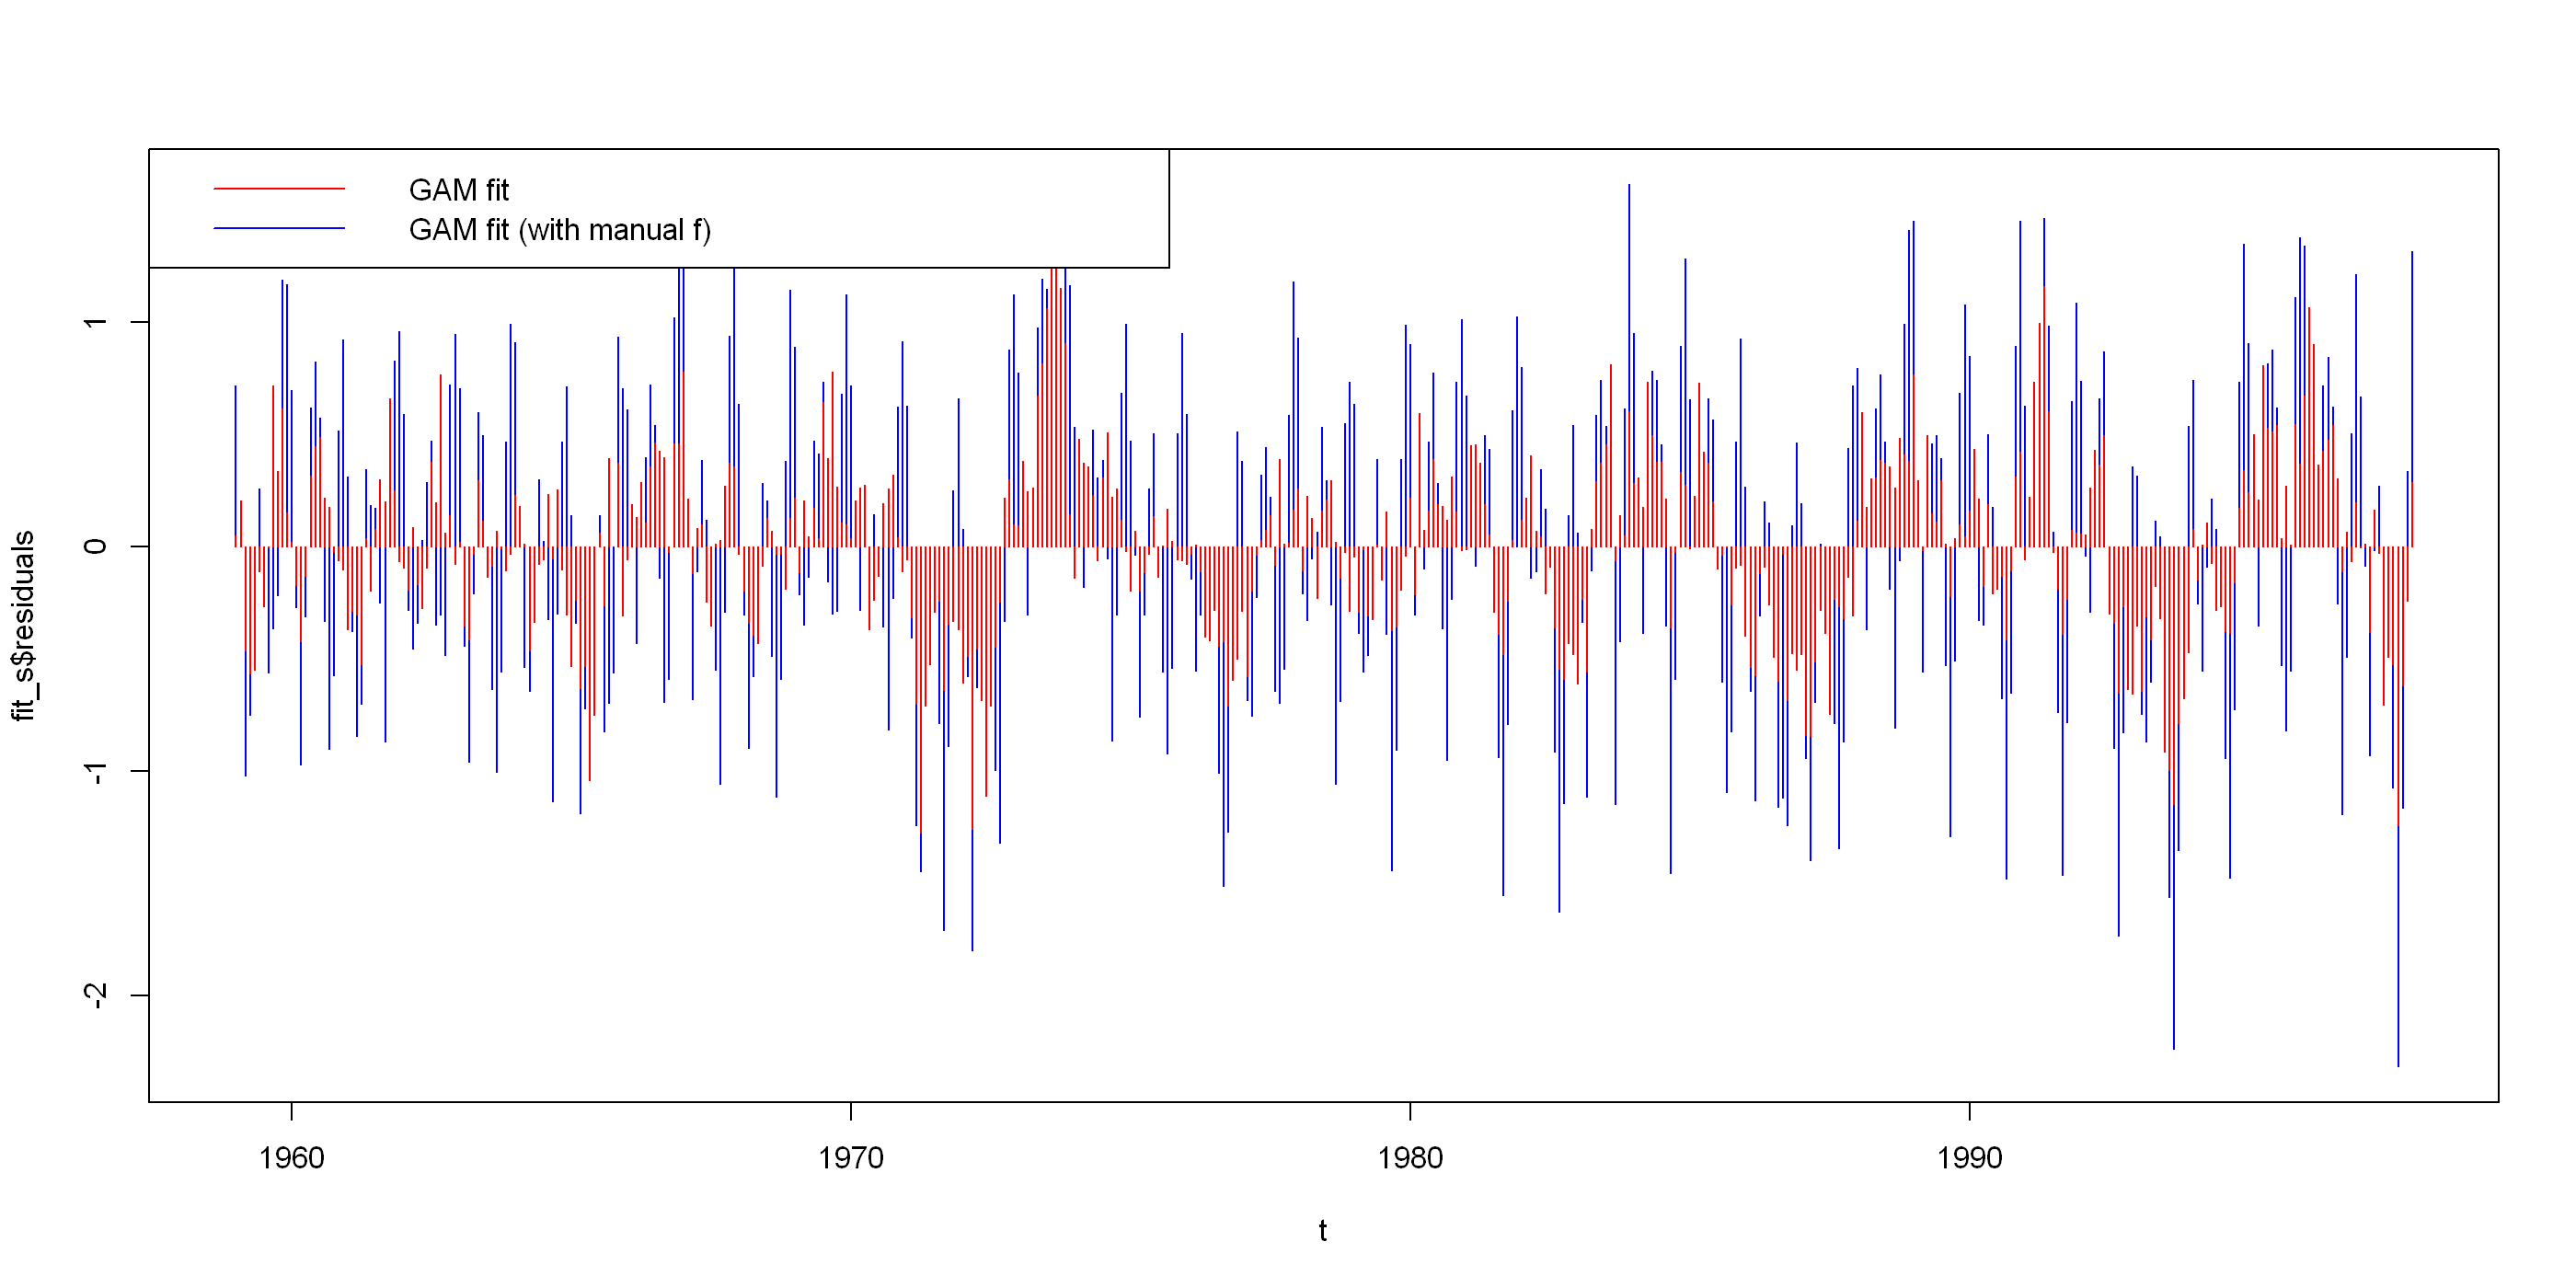

In [221]:
f<-function(t,beta1,beta2){beta1*sin(2*pi*t)+beta2*cos(2*pi*t)}
f_s <- f(I_closed/period,2,-2)
fit_s <- gam(co2~s(J_closed)+f_s)
plot(t,fit_s$fitted.values,col="blue",type='l')
lines(as.numeric(t),fit$fitted.values,col="red",type='l')
lines(as.numeric(t),co2,type='p')
legend("topleft", legend=c("Observed","GAM fit","GAM fit (with manual f)"), col=c("black","red","blue"), lty=1)


plot(t,fit_s$residuals,col="blue",type='h')
lines(as.numeric(t),fit$residuals,col="red",type='h')
legend("topleft", legend=c("GAM fit","GAM fit (with manual f)"), col=c("red","blue"), lty=1)



## 3

![ex2_3.png](ex2_3.png)

### a

![ex2_3_a.png](ex2_3_a.png)

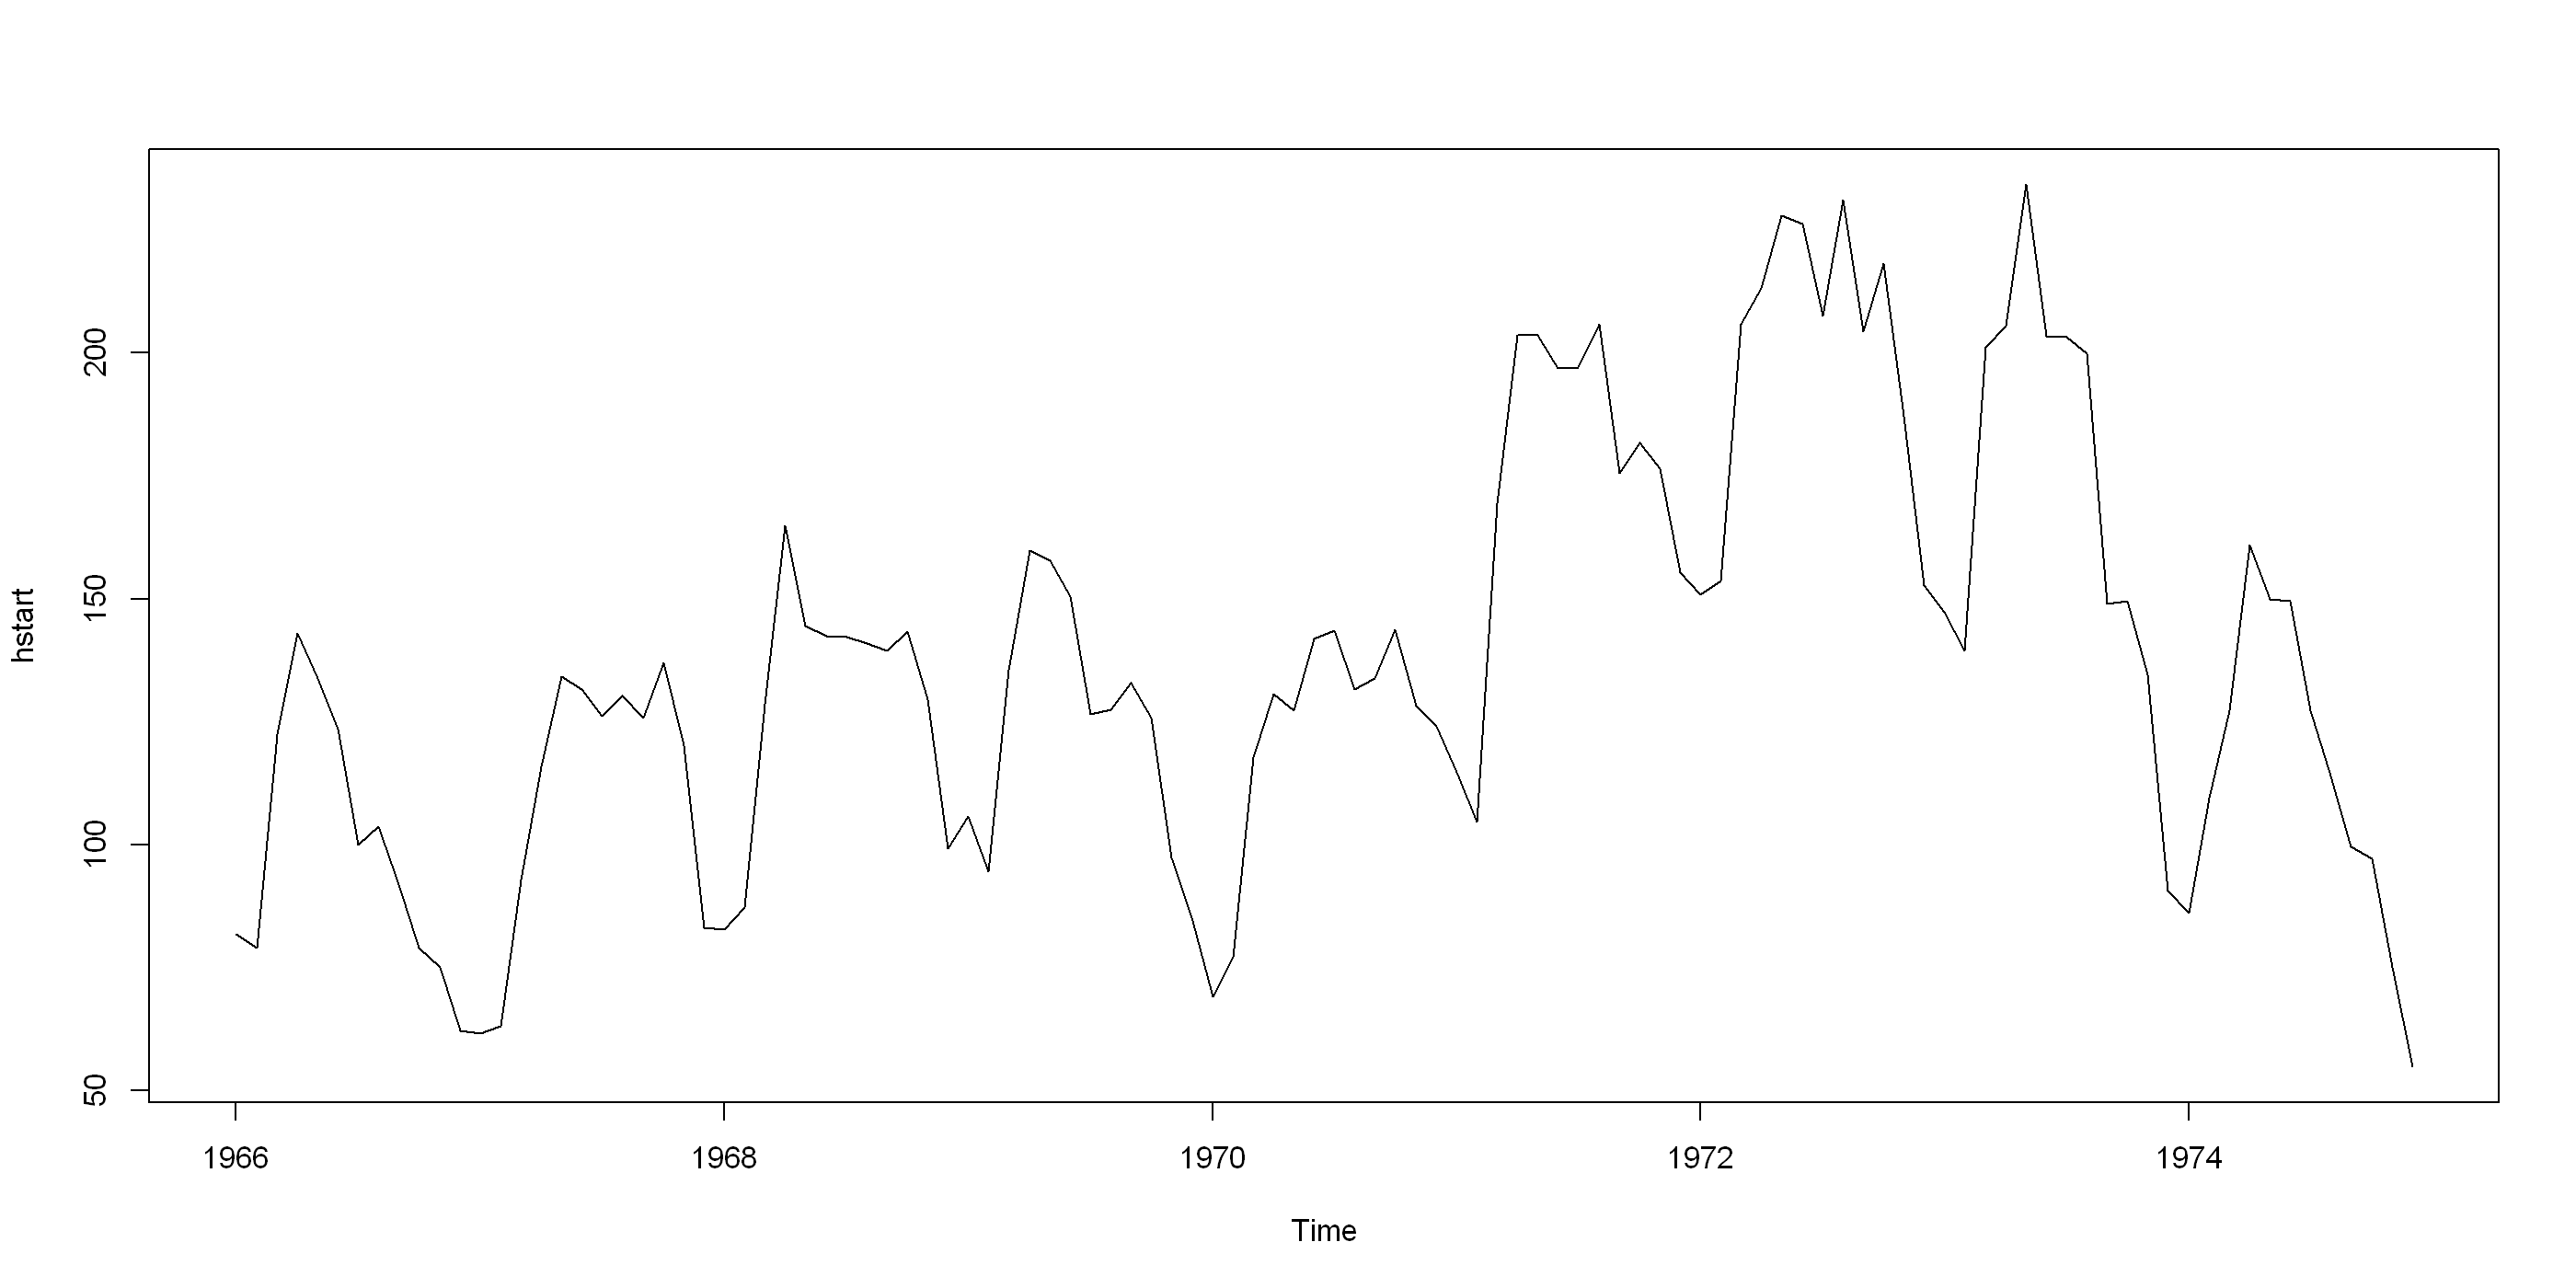

In [222]:
hstart <- read.table("https://stat.ethz.ch/Teaching/Datasets/WBL/hstart.dat")
hstart <- ts(hstart[, 1], start =c(1966,1),end=c(1974,12), frequency = 12)
plot(hstart)

No this time series is not stationary for there is a increase in the average, one could compare (1966-1970 and 1971-1974 for instance), there is a step-like trend almost polynomial like trend. This could be split into a trend and seasonality respectively and then ofcourse the standard random stationary part.

![ex2_3_b.png](ex2_3_b.png)

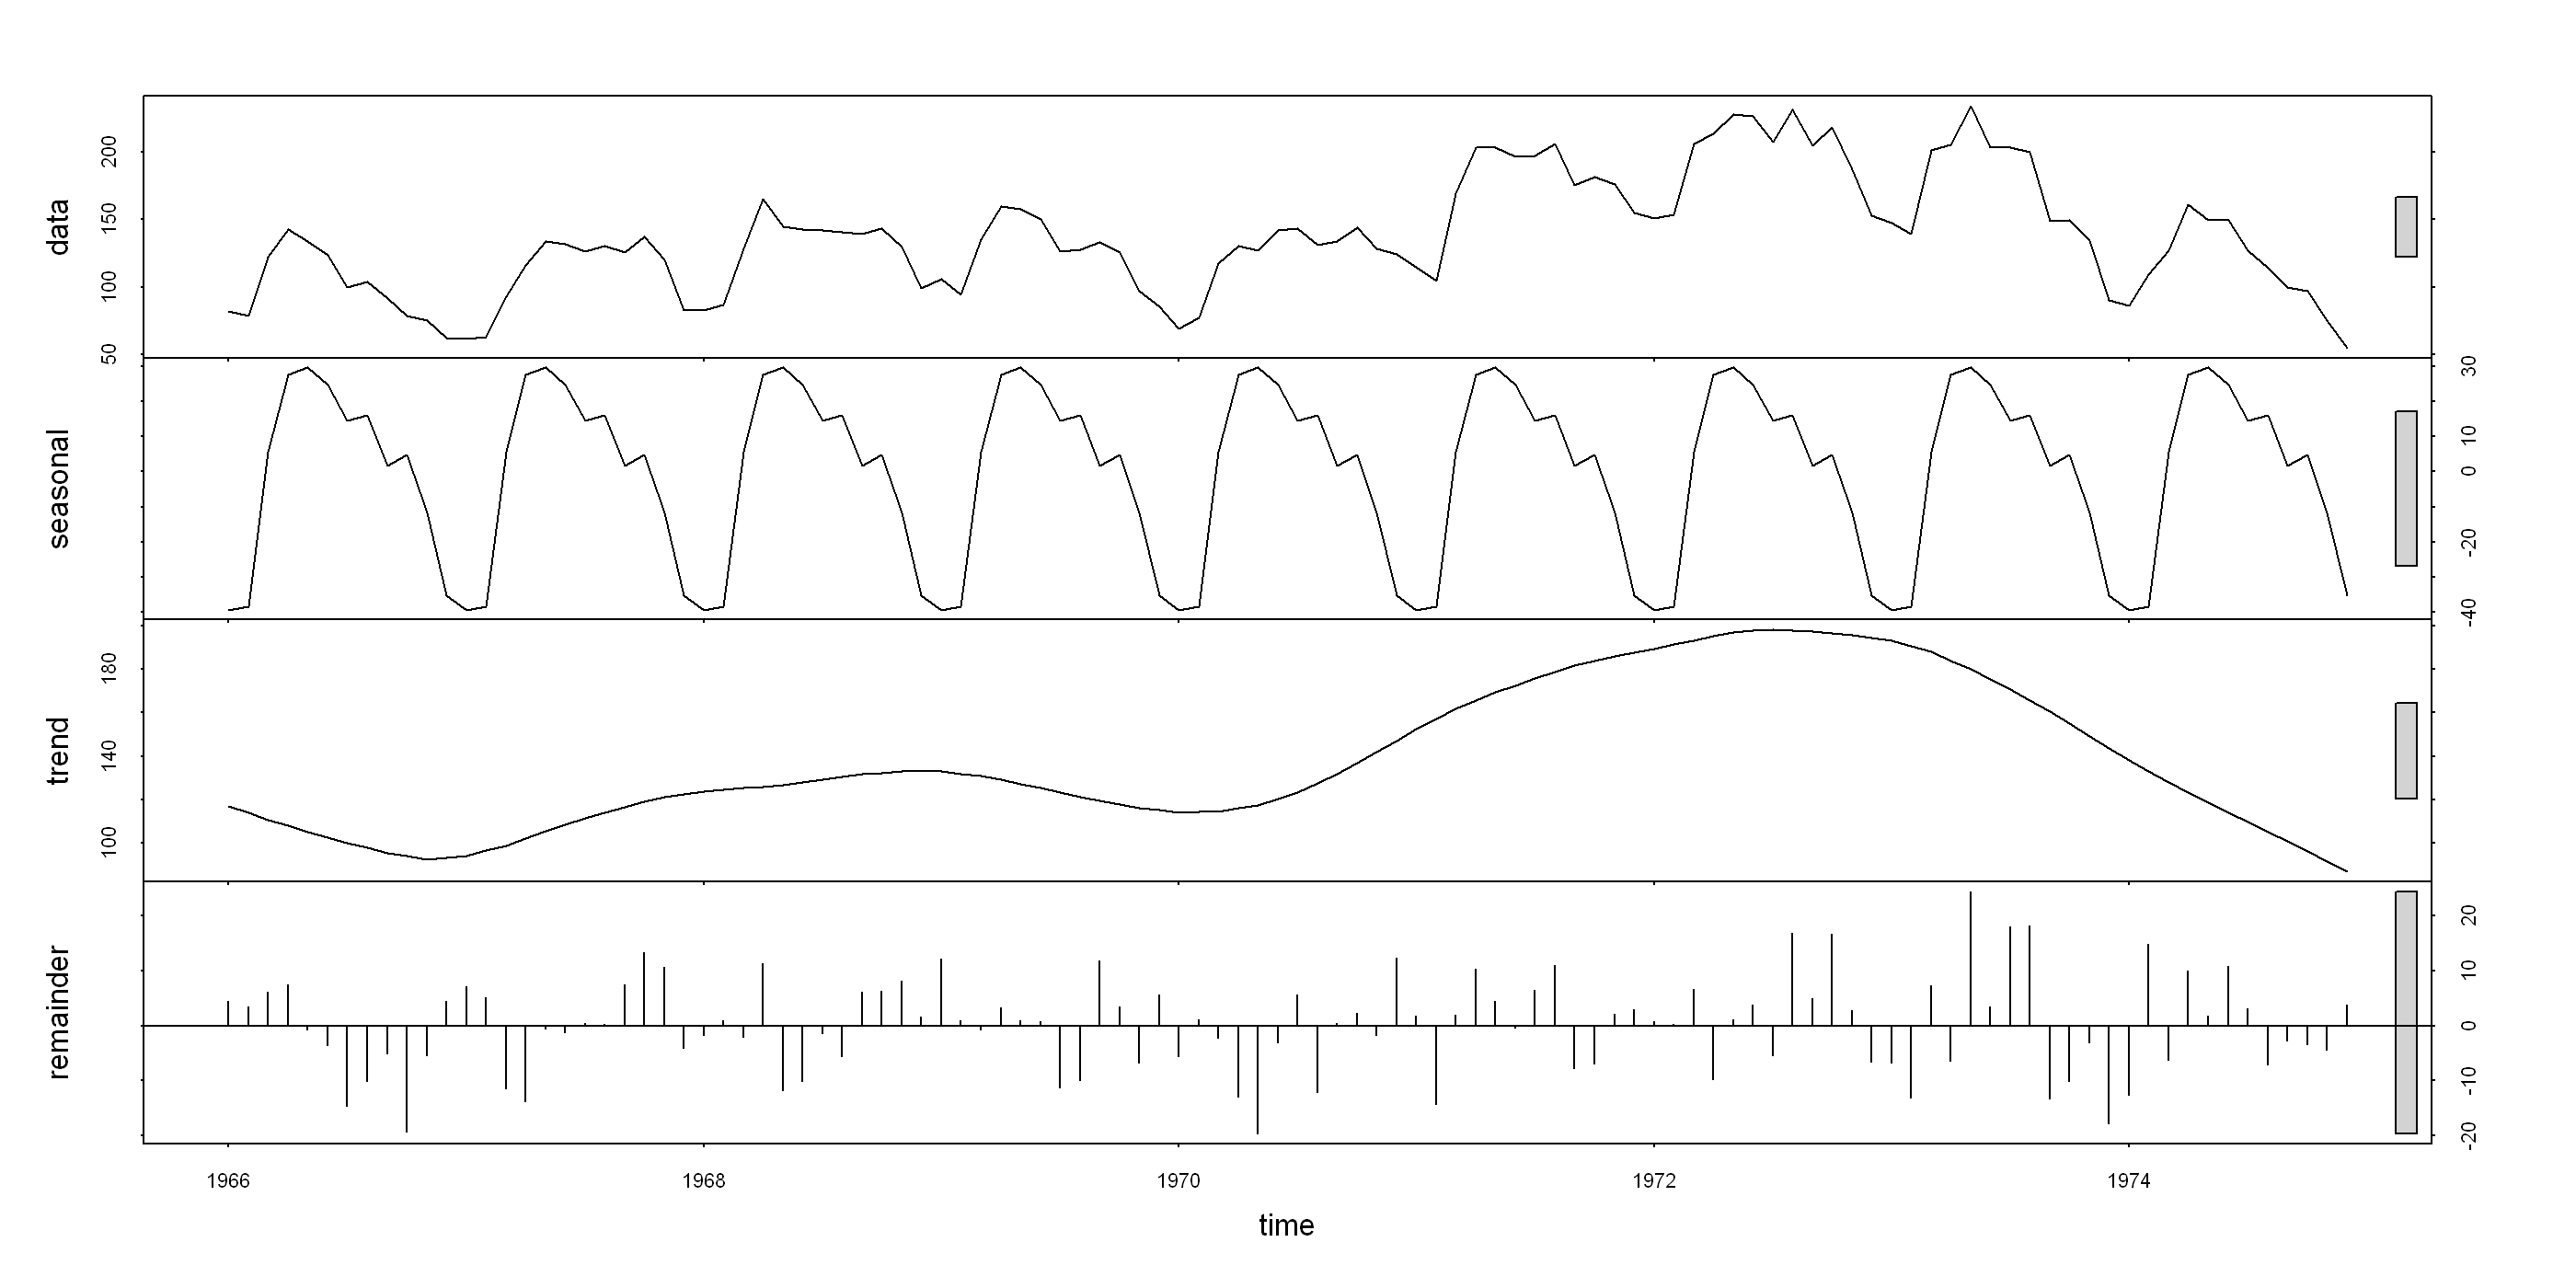

In [240]:
H.stl <- stl(hstart,s.window = "periodic")
plot(H.stl)

![ex2_3_c.png](ex2_3_c.png)

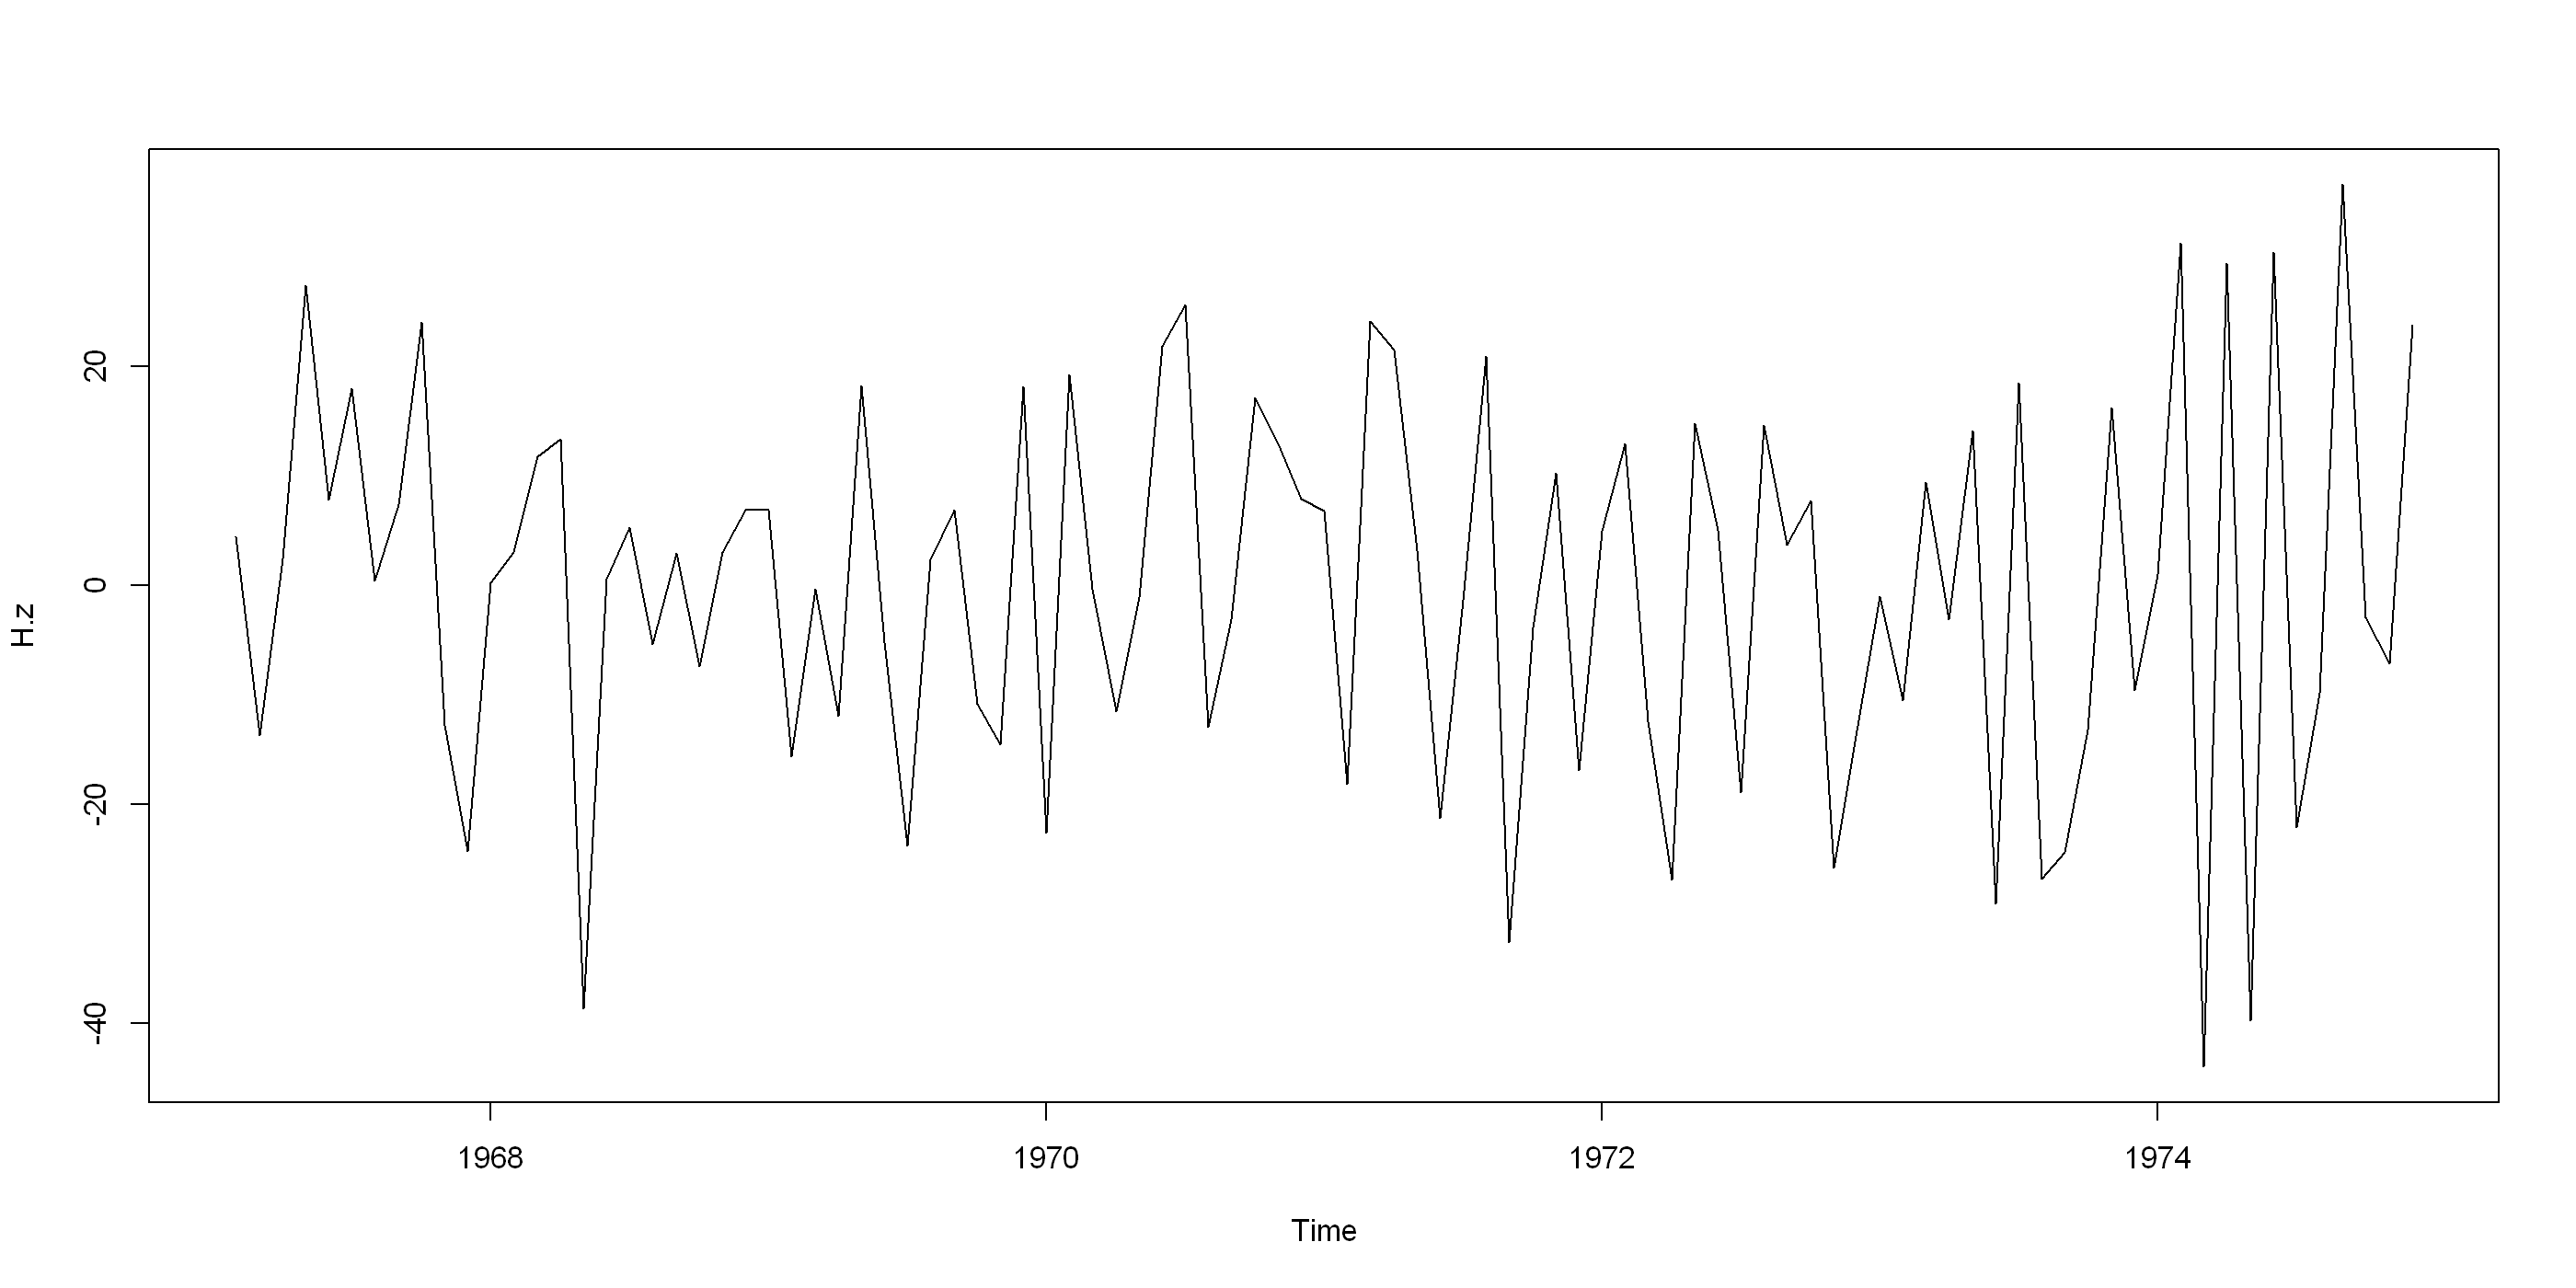

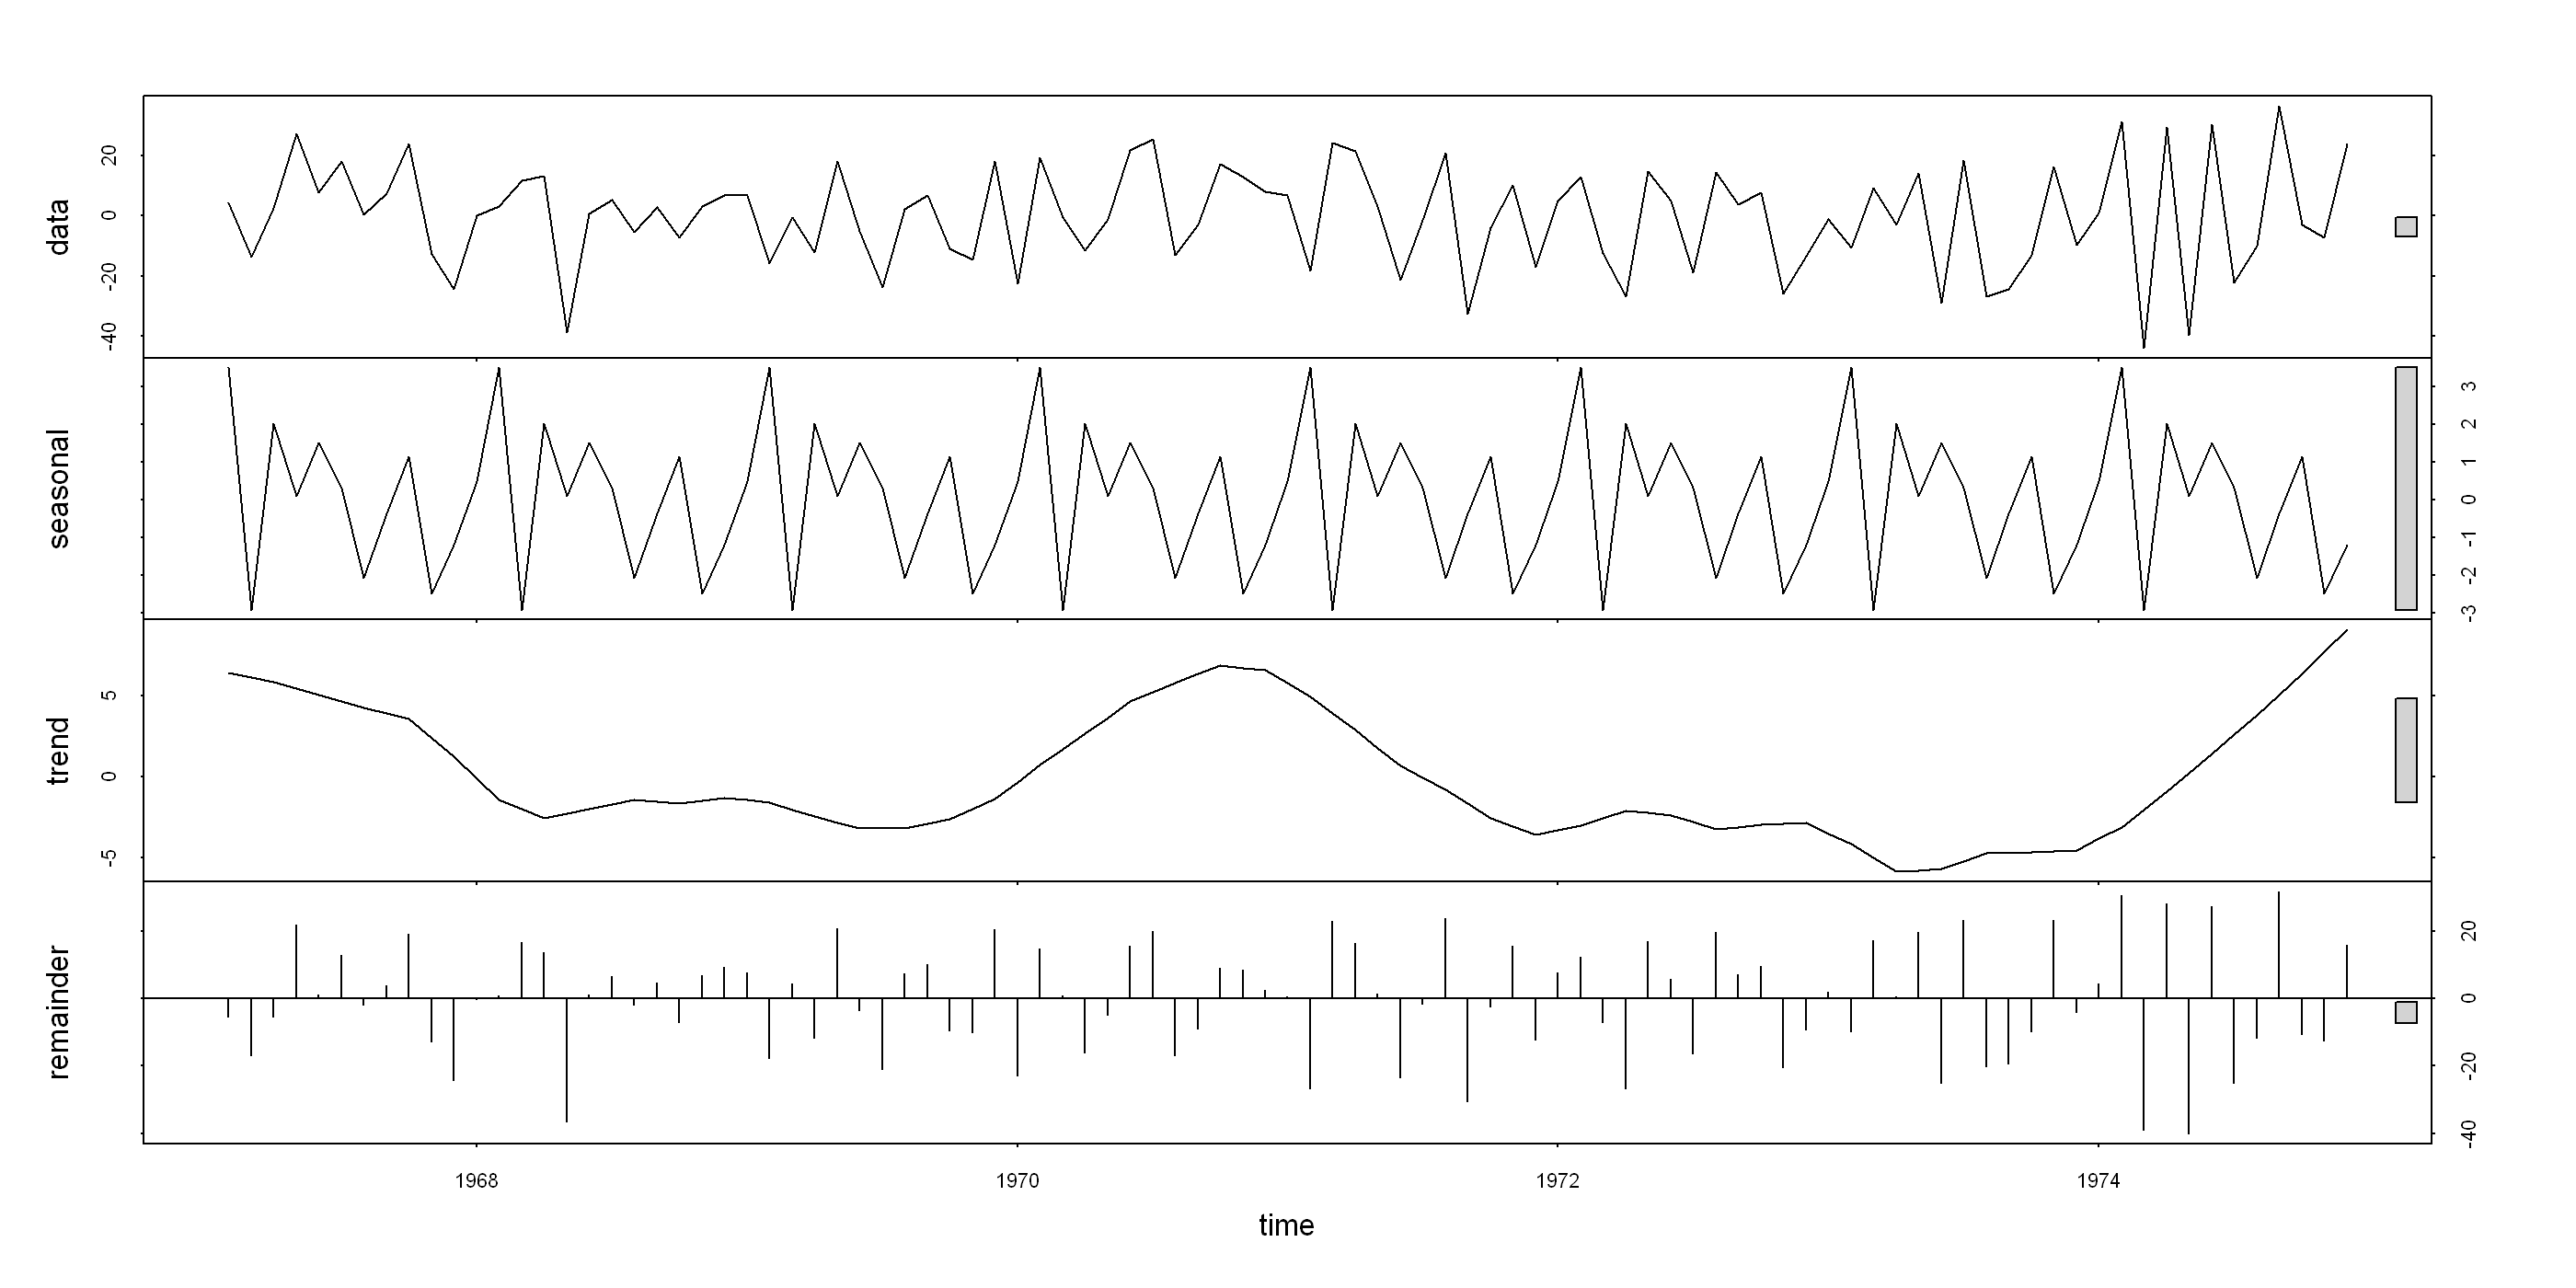

In [241]:
freq = (frequency(hstart))
H.y <-diff(hstart,lag=freq*1) # approximately the period of the seasonality
H.z <-diff(H.y,lag=1) # the usual 
plot(H.z) # roughly stationary
plot(stl(H.z,s.window = "periodic"))